<a href="https://colab.research.google.com/github/kitlapp/NLP-Course/blob/main/pr_04_supervised_learning_and_xai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Objective and Connection to Previous Work

This notebook completes the **Classification & Explainable AI (XAI)** part of the NLP group project.

It follows the same source connection used in `pr_01_data_collection_and_preprocessing.ipynb`:

```python
kagglehub.dataset_download("rohanharode07/webmd-drug-reviews-dataset")
```

The notebook therefore **does not depend on** `df_lem_final.parquet`, `df_non_lem_final.parquet`,
`source_manifest.json`, `README_RUN.md`, or any folder previously generated for Notebook 04.
It downloads/loads the original WebMD source, applies the relevant preprocessing logic from
Notebook 01 to the supervised sample, and then runs all ML, DL, evaluation, XAI, and error-analysis steps.

The main task is three-class sentiment classification:

- Satisfaction 1–2 → **Negative**
- Satisfaction 3 → **Neutral**
- Satisfaction 4–5 → **Positive**

Only review text is used as model input. Rating columns and metadata are excluded from training
to prevent leakage; metadata is retained only for post-hoc error analysis.


# 1. Environment, Imports, and Reproducibility

The next cells install only missing XAI/parquet dependencies, resolve the project root once, set fixed seeds, detect the available device, and create the notebook's own output folder.

The preferred local root is:

`C:\Users\Jannos\Documents\MS Data Science\NLP`

For portability, the code also supports the `NLP_PROJECT_ROOT` environment variable and searches sensible current/parent directories. A smoke-test mode exists only for development validation; the normal defaults remain 30,000 reviews and up to 8 BiLSTM epochs.


In [1]:
# Install only packages that are missing from the current environment.
# In a prepared local environment this cell normally does nothing.
import importlib.util
import subprocess
import sys

required_imports = {
    "kagglehub": "kagglehub",
    "nltk": "nltk",
    "lime": "lime",
    "shap": "shap",
}

missing_packages = [
    package
    for module, package in required_imports.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All notebook dependencies are already installed.")


Installing missing packages: ['lime']


In [2]:
# Standard library
from collections import Counter
from copy import deepcopy
from datetime import datetime
from importlib import metadata
from pathlib import Path
import re
import json
import os
import platform
import random
import time
import warnings

# Dataset and NLP
import kagglehub
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Data and visualization
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Scikit-learn
from scipy.special import softmax
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

# Deep learning
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

# Notebook display
from IPython.display import HTML, Markdown, display

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 50)
warnings.filterwarnings("default")

SEED = 42
CLASS_NAMES = ["Negative", "Neutral", "Positive"]
LABELS = [0, 1, 2]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Limit CPU thread oversubscription, which can make small/medium LSTM workloads much slower.
CPU_THREADS = max(1, min(4, os.cpu_count() or 1))
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Deterministic settings improve reproducibility. Some CUDA operations may still vary slightly.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NOTEBOOK_START_TIME = time.perf_counter()
RUN_STARTED_AT = datetime.now().isoformat(timespec="seconds")

# Normal/default run: 30,000 rows and up to 8 epochs.
# Development smoke mode is explicit and prints a warning.
SMOKE_TEST = os.environ.get("NLP_SMOKE_TEST", "0") == "1"
SAMPLE_SIZE = int(os.environ.get("NLP_SAMPLE_SIZE", "30000"))
MAX_EPOCHS = int(os.environ.get("NLP_MAX_EPOCHS", "8"))

if SMOKE_TEST:
    SAMPLE_SIZE = min(SAMPLE_SIZE, 600)
    MAX_EPOCHS = min(MAX_EPOCHS, 1)
    print("SMOKE TEST MODE: reduced rows/epochs are used only for code validation, not final results.")

print("Python:", platform.python_version())
print("Device:", DEVICE)
print("PyTorch CPU threads:", CPU_THREADS)
print("Seed:", SEED)
print("Configured sample size:", f"{SAMPLE_SIZE:,}")
print("Maximum BiLSTM epochs:", MAX_EPOCHS)

for package_name in ["pandas", "numpy", "scikit-learn", "scipy", "matplotlib", "torch", "nltk", "kagglehub", "lime", "shap"]:
    try:
        print(f"{package_name}: {metadata.version(package_name)}")
    except metadata.PackageNotFoundError:
        print(f"{package_name}: not installed")


Python: 3.12.13
Device: cpu
PyTorch CPU threads: 2
Seed: 42
Configured sample size: 30,000
Maximum BiLSTM epochs: 8
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
scipy: 1.16.3
matplotlib: 3.10.0
torch: 2.11.0+cpu
nltk: 3.9.1
kagglehub: 1.0.2
lime: 0.2.0.1
shap: 0.52.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# Use the exact local project folder shown in the project structure.
# If the notebook is moved, the current working directory is used instead.
PREFERRED_PROJECT_ROOT = Path(
    r"C:\Users\Jannos\Documents\MS Data Science\NLP\Project NLP"
)

if PREFERRED_PROJECT_ROOT.exists():
    PROJECT_ROOT = PREFERRED_PROJECT_ROOT
else:
    PROJECT_ROOT = Path.cwd().resolve()
    # When run from an older generated subfolder, save beside notebooks 1-3.
    if PROJECT_ROOT.name in {
        "NLP_Classification_XAI_Executed",
        "04_Classification_XAI",
    }:
        PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "supervised_xai"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Same source connection as pr_01_data_collection_and_preprocessing.ipynb.
DATASET_ID = "rohanharode07/webmd-drug-reviews-dataset"
dataset_path = Path(kagglehub.dataset_download(DATASET_ID))

raw_filepath = dataset_path / "webmd.csv"
if not raw_filepath.exists():
    csv_candidates = sorted(dataset_path.rglob("webmd.csv"))
    if not csv_candidates:
        csv_candidates = sorted(dataset_path.rglob("*.csv"))
    if not csv_candidates:
        raise FileNotFoundError(
            f"No CSV file was found in the Kaggle dataset directory: {dataset_path}"
        )
    raw_filepath = csv_candidates[0]

RAW_DATA_PATH = raw_filepath

print("Project folder:", PROJECT_ROOT)
print("Kaggle dataset ID:", DATASET_ID)
print("Dataset cache folder:", dataset_path)
print("Raw source file:", RAW_DATA_PATH)
print("Artifacts will be saved to:", ARTIFACT_DIR)


100%|██████████| 43.4M/43.4M [00:00<00:00, 113MB/s]

Extracting files...


Project folder: /content
Kaggle dataset ID: rohanharode07/webmd-drug-reviews-dataset
Dataset cache folder: /root/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1
Raw source file: /root/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1/webmd.csv
Artifacts will be saved to: /content/artifacts/supervised_xai


In [4]:
# Read the original WebMD dataset directly, exactly as Notebook 01 does.
df_raw = pd.read_csv(RAW_DATA_PATH)

required_source_columns = {
    "Reviews",
    "Satisfaction",
    "Effectiveness",
    "EaseofUse",
}
missing_source_columns = required_source_columns.difference(df_raw.columns)
if missing_source_columns:
    raise KeyError(
        "The WebMD source file is missing required columns: "
        f"{sorted(missing_source_columns)}"
    )

print("Raw dataset shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
display(df_raw.head(2))


Raw dataset shape: (362806, 12)
Columns: ['Age', 'Condition', 'Date', 'Drug', 'DrugId', 'EaseofUse', 'Effectiveness', 'Reviews', 'Satisfaction', 'Sex', 'Sides', 'UsefulCount']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I have tried for my allergies (seasonal and not) - this one is the most effective for me. When I first began using this drug some y...,5,Male,"Drowsiness, dizziness , dry mouth /nose/throat, headache , upset stomach , constipation , or trouble sleeping may occur.",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurting it went away after taking the medicine,5,Female,"Drowsiness, dizziness , dry mouth /nose/throat, headache , upset stomach , constipation , or trouble sleeping may occur.",1


# 2. Download and Prepare the Source Data

The notebook connects to the original Kaggle source with the same logic as Notebook 01.
It then reproduces the relevant preprocessing decisions:

- remove missing and exact duplicate rows;
- keep valid 1–5 rating values;
- remove empty, punctuation-only, one-character, repeated-character, and null-like reviews;
- lowercase and normalize text;
- handle URLs, usernames, emojis, repeated letters, short words, and stopwords;
- preserve the sentiment-bearing negations `no`, `not`, `nor`, and `never`;
- create both non-lemmatized and POS-aware lemmatized review text.

To keep Notebook 04 practical, the expensive text normalization and lemmatization are applied
only to the duplicate-safe stratified candidate sample used for supervised modeling.


In [5]:
# Structural preprocessing copied from the logic of Notebook 01.
df = df_raw.copy()
rows_initial = len(df)

score_columns = ["Satisfaction", "Effectiveness", "EaseofUse"]
for column in score_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Notebook 01 removes rows with missing values and exact duplicates.
df = df.dropna().drop_duplicates().reset_index(drop=True)
rows_after_missing_duplicates = len(df)

# Keep only valid five-star values.
valid_scores = np.logical_and.reduce(
    [df[column].between(1, 5) for column in score_columns]
)
df = df.loc[valid_scores].reset_index(drop=True)
rows_after_scores = len(df)

reviews = df["Reviews"].astype(str)
stripped_reviews = reviews.str.strip()

punctuation_only = stripped_reviews.apply(
    lambda text: bool(re.fullmatch(r"[\W_]+", text))
)
single_character = stripped_reviews.str.len().eq(1)
repeated_single_character = stripped_reviews.str.lower().apply(
    lambda text: bool(re.fullmatch(r"(.)\1+", text))
)
null_like = stripped_reviews.str.lower().isin(
    {"none", "nan", "null", "n/a", "na"}
)
empty_review = stripped_reviews.eq("")

valid_review_mask = ~(
    empty_review
    | punctuation_only
    | single_character
    | repeated_single_character
    | null_like
)
df = df.loc[valid_review_mask].reset_index(drop=True)

print(f"Initial rows: {rows_initial:,}")
print(
    "After missing-value and exact-row duplicate removal:",
    f"{rows_after_missing_duplicates:,}",
)
print("After five-star score validation:", f"{rows_after_scores:,}")
print("NLP-usable rows after review validation:", f"{len(df):,}")


Initial rows: 362,806
After missing-value and exact-row duplicate removal: 361,820
After five-star score validation: 361,817
NLP-usable rows after review validation: 319,934


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# Download the same NLTK resources used by Notebook 01 when they are unavailable.
nltk_resources = [
    ("stopwords", "corpora/stopwords"),
    ("wordnet", "corpora/wordnet"),
    ("omw-1.4", "corpora/omw-1.4"),
    ("averaged_perceptron_tagger_eng", "taggers/averaged_perceptron_tagger_eng"),
]

for package_name, resource_path in nltk_resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(package_name, quiet=True)

base_stopwords = set(stopwords.words("english"))
PRESERVED_NEGATIONS = {"no", "not", "nor", "never"}
custom_stopwords = base_stopwords - PRESERVED_NEGATIONS

url_pattern = re.compile(r"(?:https?|ftp)://[^\s/$.?#].[^\s]*")
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\u2700-\u27BF"
    u"\U0001F900-\U0001F9FF"
    u"\U0001FA70-\U0001FAFF"
    u"\u2600-\u26FF"
    "]+",
    flags=re.UNICODE,
)
emoticon_pattern = re.compile(
    r"(:\)|:\(|:D|:P|;\)|:-\)|:-D|:-P|:\'\(|:\||:\*)"
)


def normalize_review(text: str) -> str:
    """Apply the relevant non-lemmatizing text logic from Notebook 01."""
    text = str(text).lower()

    # URLs, emojis/emoticons, emails, and @usernames.
    text = url_pattern.sub(" url ", text)
    text = emoji_pattern.sub(" ", text)
    text = emoticon_pattern.sub(" ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " user ", text)
    text = re.sub(r"(?:(?<=^)|(?<=[\s.,;!?]))@\w+\b", " user ", text)

    # Keep letters, spaces, and the punctuation retained in Notebook 01.
    text = re.sub(r"[^a-z\s.!?]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Limit elongated character sequences to two characters.
    text = re.sub(r"(\w)\1{2,}", r"\1\1", text)

    # Remove very short words while preserving important negation words.
    words = [
        word
        for word in text.split()
        if len(word) >= 3 or word.lower() in {"no", "not"}
    ]

    # Remove stopwords but retain no/not/nor/never.
    words = [word for word in words if word not in custom_stopwords]
    return " ".join(words)


def get_wordnet_pos(tag: str):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


lemmatizer = WordNetLemmatizer()


def lemmatize_review(cleaned_text: str) -> str:
    """POS-aware WordNet lemmatization, matching Notebook 01."""
    words = str(cleaned_text).split()
    if not words:
        return ""
    tagged_words = pos_tag(words)
    return " ".join(
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_words
    )


print("Text preprocessing functions are ready.")


Text preprocessing functions are ready.


# 3. Create the Sentiment Target and Prevent Leakage

The target comes only from `Satisfaction`. The model input remains review text only.
Duplicate review text is controlled both before and after normalization so identical text
cannot cross the train/validation/test boundaries.


In [7]:
# Build the supervised source table from the Kaggle data.
metadata_columns = [
    column
    for column in ["DrugId", "Drug", "Condition", "Age", "Sex", "Date", "UsefulCount"]
    if column in df.columns
]

master = df[metadata_columns].copy()
master.insert(0, "row_id", np.arange(len(master), dtype=np.int64))
master["review_raw"] = df["Reviews"].astype(str)
master["Satisfaction"] = pd.to_numeric(df["Satisfaction"], errors="coerce")


def map_sentiment(score):
    if score in (1, 2):
        return 0
    if score == 3:
        return 1
    if score in (4, 5):
        return 2
    return np.nan


master["target"] = master["Satisfaction"].map(map_sentiment)
master = master[master["target"].notna()].copy()
master["target"] = master["target"].astype(int)
master["sentiment"] = master["target"].map(dict(enumerate(CLASS_NAMES)))

# Raw-text duplicate key before expensive NLP processing.
master["raw_review_key"] = (
    master["review_raw"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

raw_label_counts = master.groupby("raw_review_key", sort=False)["target"].nunique()
raw_conflicting_keys = raw_label_counts[raw_label_counts > 1].index
raw_conflicting_rows = int(
    master["raw_review_key"].isin(raw_conflicting_keys).sum()
)

master = master[~master["raw_review_key"].isin(raw_conflicting_keys)].copy()
rows_before_raw_dedup = len(master)
master_unique_raw = master.drop_duplicates(
    subset="raw_review_key",
    keep="first",
).copy()
raw_duplicate_rows = rows_before_raw_dedup - len(master_unique_raw)

print("Target labels:", dict(enumerate(CLASS_NAMES)))
print(f"Raw conflicting text groups removed: {len(raw_conflicting_keys):,}")
print(f"Rows in raw conflicting groups removed: {raw_conflicting_rows:,}")
print(f"Additional exact raw-text duplicates removed: {raw_duplicate_rows:,}")
print(f"Unique usable raw reviews: {len(master_unique_raw):,}")


Target labels: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
Raw conflicting text groups removed: 384
Rows in raw conflicting groups removed: 2,928
Additional exact raw-text duplicates removed: 68,017
Unique usable raw reviews: 248,989


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
class_distribution = (
    master_unique_raw["target"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
    .rename("Count")
    .to_frame()
)
class_distribution["Percentage"] = (
    class_distribution["Count"] / len(master_unique_raw) * 100
)
class_distribution.index = CLASS_NAMES
display(class_distribution.round(2))

excluded_training_columns = [
    "Satisfaction",
    "Effectiveness",
    "EaseofUse",
    "Scores_Avg",
    "Age",
    "Sex",
    "Condition",
    "Drug",
    "DrugId",
    "Date",
    "UsefulCount",
]
print("Excluded from model input:", excluded_training_columns)


,Count,Percentage
Negative,100543,40.38
Neutral,32991,13.25
Positive,115455,46.37


Excluded from model input: ['Satisfaction', 'Effectiveness', 'EaseofUse', 'Scores_Avg', 'Age', 'Sex', 'Condition', 'Drug', 'DrugId', 'Date', 'UsefulCount']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 4. Shared Stratified Sample and Train/Validation/Test Split

A slightly larger stratified candidate pool is selected first. The preprocessing logic from
Notebook 01 is then applied only to this candidate pool. Empty normalized texts and any
duplicates created by normalization are removed, after which the final shared sample of
up to 30,000 rows is selected and split 70%/15%/15%.


In [9]:
def take_stratified_sample(
    dataframe: pd.DataFrame,
    sample_size: int,
) -> pd.DataFrame:
    if sample_size >= len(dataframe):
        return (
            dataframe.sample(frac=1, random_state=SEED)
            .reset_index(drop=True)
        )

    sampled, _ = train_test_split(
        dataframe,
        train_size=sample_size,
        stratify=dataframe["target"],
        random_state=SEED,
    )
    return sampled.sample(frac=1, random_state=SEED).reset_index(drop=True)


# Select a small buffer so the final sample remains close to SAMPLE_SIZE
# if a few rows become empty or duplicate after text normalization.
candidate_size = min(
    len(master_unique_raw),
    max(SAMPLE_SIZE, int(np.ceil(SAMPLE_SIZE * 1.10))),
)
candidate_df = take_stratified_sample(master_unique_raw, candidate_size)

print(f"Preprocessing {len(candidate_df):,} candidate reviews...")
candidate_df["review_non_lem"] = candidate_df["review_raw"].apply(
    normalize_review
)
candidate_df["review_lem"] = candidate_df["review_non_lem"].apply(
    lemmatize_review
)

rows_before_empty_check = len(candidate_df)
candidate_df = candidate_df[
    candidate_df["review_non_lem"].str.strip().ne("")
    & candidate_df["review_lem"].str.strip().ne("")
].copy()
print(
    "Rows removed because normalized text became empty:",
    f"{rows_before_empty_check - len(candidate_df):,}",
)

# A second duplicate control is necessary because normalization may make
# originally different strings identical.
candidate_df["review_key"] = (
    candidate_df["review_non_lem"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

clean_label_counts = candidate_df.groupby(
    "review_key",
    sort=False,
)["target"].nunique()
clean_conflicting_keys = clean_label_counts[
    clean_label_counts > 1
].index
clean_conflicting_rows = int(
    candidate_df["review_key"].isin(clean_conflicting_keys).sum()
)

candidate_df = candidate_df[
    ~candidate_df["review_key"].isin(clean_conflicting_keys)
].copy()
rows_before_clean_dedup = len(candidate_df)
candidate_df = candidate_df.drop_duplicates(
    subset="review_key",
    keep="first",
).copy()
clean_duplicate_rows = rows_before_clean_dedup - len(candidate_df)

print(f"Cleaned conflicting text groups removed: {len(clean_conflicting_keys):,}")
print(f"Rows in cleaned conflicting groups removed: {clean_conflicting_rows:,}")
print(f"Additional cleaned-text duplicates removed: {clean_duplicate_rows:,}")

sample_df = take_stratified_sample(candidate_df, SAMPLE_SIZE)

train_df, temporary_df = train_test_split(
    sample_df,
    test_size=0.30,
    stratify=sample_df["target"],
    random_state=SEED,
)
validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["target"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_frames = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for left_name, left_df in split_frames.items():
    for right_name, right_df in split_frames.items():
        if left_name >= right_name:
            continue
        assert set(left_df["row_id"]).isdisjoint(set(right_df["row_id"]))
        assert set(left_df["review_key"]).isdisjoint(set(right_df["review_key"]))

assert len(train_df) + len(validation_df) + len(test_df) == len(sample_df)
assert set(sample_df["target"].unique()) == set(LABELS)

print(f"Shared final sample: {len(sample_df):,}")
print(f"Train: {len(train_df):,} ({len(train_df) / len(sample_df):.1%})")
print(
    f"Validation: {len(validation_df):,} "
    f"({len(validation_df) / len(sample_df):.1%})"
)
print(f"Test: {len(test_df):,} ({len(test_df) / len(sample_df):.1%})")

split_distribution_rows = []
for split_name, dataframe in {
    "Full sample": sample_df,
    **split_frames,
}.items():
    counts = (
        dataframe["target"]
        .value_counts(normalize=True)
        .reindex(LABELS, fill_value=0)
    )
    split_distribution_rows.append(
        {
            "Split": split_name,
            **{
                CLASS_NAMES[label]: counts.loc[label]
                for label in LABELS
            },
        }
    )

split_distribution = pd.DataFrame(
    split_distribution_rows
).set_index("Split")
display((split_distribution * 100).round(2).add_suffix(" %"))


Preprocessing 33,000 candidate reviews...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rows removed because normalized text became empty: 4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cleaned conflicting text groups removed: 15
Rows in cleaned conflicting groups removed: 32
Additional cleaned-text duplicates removed: 16
Shared final sample: 30,000
Train: 21,000 (70.0%)
Validation: 4,500 (15.0%)
Test: 4,500 (15.0%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Negative %,Neutral %,Positive %
Split,,,
Full sample,40.39,13.23,46.39
train,40.39,13.23,46.39
validation,40.38,13.22,46.40
test,40.40,13.22,46.38


In [10]:
split_ids = pd.concat(
    [
        dataframe[["row_id", "target"]].assign(split=split_name)
        for split_name, dataframe in split_frames.items()
    ],
    ignore_index=True,
)
split_ids.to_csv(ARTIFACT_DIR / "split_ids.csv", index=False)
print("Saved reproducible split IDs to:", ARTIFACT_DIR / "split_ids.csv")


Saved reproducible split IDs to: /content/artifacts/supervised_xai/split_ids.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 5. Traditional Machine-Learning Models

The traditional models use the lemmatized review text:

1. `DummyClassifier(strategy="most_frequent")` as the majority baseline;
2. TF-IDF + Logistic Regression;
3. TF-IDF + LinearSVC.

The TF-IDF vectorizer is inside each scikit-learn pipeline, so it is fitted only on the current training text. Logistic Regression and LinearSVC compare `C = 0.5, 1.0, 2.0` on validation macro F1. The selected setting is then refitted on training + validation data before one final test evaluation.


In [11]:
TFIDF_MAX_FEATURES = 10_000
TFIDF_PARAMETERS = {
    "max_features": TFIDF_MAX_FEATURES,
    "min_df": 5,
    "max_df": 0.8,
    "ngram_range": (1, 2),
    "sublinear_tf": True,
}
C_VALUES = [0.5, 1.0, 2.0]


def make_vectorizer(max_features: int) -> TfidfVectorizer:
    return TfidfVectorizer(
        max_features=max_features,
        min_df=TFIDF_PARAMETERS["min_df"],
        max_df=TFIDF_PARAMETERS["max_df"],
        ngram_range=TFIDF_PARAMETERS["ngram_range"],
        sublinear_tf=TFIDF_PARAMETERS["sublinear_tf"],
    )


def make_logistic_pipeline(c_value: float, max_features: int) -> Pipeline:
    return Pipeline([
        ("tfidf", make_vectorizer(max_features)),
        ("classifier", LogisticRegression(
            C=c_value,
            class_weight="balanced",
            max_iter=1_000,
            solver="lbfgs",
            random_state=SEED,
        )),
    ])


def make_svm_pipeline(c_value: float, max_features: int) -> Pipeline:
    return Pipeline([
        ("tfidf", make_vectorizer(max_features)),
        ("classifier", LinearSVC(
            C=c_value,
            class_weight="balanced",
            random_state=SEED,
        )),
    ])


def tune_pipeline(model_name, pipeline_factory, max_features):
    rows = []
    for c_value in C_VALUES:
        pipeline = pipeline_factory(c_value, max_features)
        start = time.perf_counter()
        pipeline.fit(train_df["review_lem"], train_df["target"])
        fit_seconds = time.perf_counter() - start
        validation_predictions = pipeline.predict(validation_df["review_lem"])
        macro_f1 = f1_score(
            validation_df["target"], validation_predictions,
            labels=LABELS, average="macro", zero_division=0,
        )
        rows.append({
            "Model": model_name,
            "C": c_value,
            "Validation Macro F1": macro_f1,
            "Fit Time (s)": fit_seconds,
        })
        print(f"{model_name}, C={c_value}: validation macro F1={macro_f1:.4f}")
    results = pd.DataFrame(rows).sort_values(
        ["Validation Macro F1", "C"], ascending=[False, True]
    ).reset_index(drop=True)
    return results, float(results.loc[0, "C"])


try:
    lr_tuning, best_lr_c = tune_pipeline(
        "Logistic Regression", make_logistic_pipeline, TFIDF_MAX_FEATURES
    )
    svm_tuning, best_svm_c = tune_pipeline(
        "Linear SVM", make_svm_pipeline, TFIDF_MAX_FEATURES
    )
except MemoryError:
    TFIDF_MAX_FEATURES = 5_000
    print("MemoryError at 10,000 TF-IDF features. Retrying transparently with 5,000 features.")
    lr_tuning, best_lr_c = tune_pipeline(
        "Logistic Regression", make_logistic_pipeline, TFIDF_MAX_FEATURES
    )
    svm_tuning, best_svm_c = tune_pipeline(
        "Linear SVM", make_svm_pipeline, TFIDF_MAX_FEATURES
    )

validation_comparison = pd.concat([lr_tuning, svm_tuning], ignore_index=True)
display(validation_comparison.sort_values(["Model", "C"]).round(4))
print("Selected Logistic Regression C:", best_lr_c)
print("Selected Linear SVM C:", best_svm_c)
print("Final TF-IDF max_features:", TFIDF_MAX_FEATURES)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logistic Regression, C=0.5: validation macro F1=0.5729


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logistic Regression, C=1.0: validation macro F1=0.5715


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Linear SVM, C=2.0: validation macro F1=0.5494


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,C,Validation Macro F1,Fit Time (s)
3,Linear SVM,0.5,0.5710,8.8263
4,Linear SVM,1.0,0.5596,3.3230
5,Linear SVM,2.0,0.5494,5.9653
0,Logistic Regression,0.5,0.5729,6.0508
1,Logistic Regression,1.0,0.5715,6.5807
2,Logistic Regression,2.0,0.5682,5.6835


Selected Logistic Regression C: 0.5
Selected Linear SVM C: 0.5
Final TF-IDF max_features: 10000


In [12]:
train_validation_df = pd.concat([train_df, validation_df], ignore_index=True)

model_results = []
model_predictions = {}
model_confidences = {}
model_probabilities = {}
classification_reports = {}
training_times = {}
inference_times = {}


def metrics_row(model_name, representation, y_true, y_pred, train_seconds, infer_seconds):
    return {
        "Model": model_name,
        "Representation": representation,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        ),
        "Training Time (s)": train_seconds,
        "Inference Time (s)": infer_seconds,
    }


def report_dataframe(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose()


def save_confusion_matrices(y_true, y_pred, model_name, filename_stem):
    raw = confusion_matrix(y_true, y_pred, labels=LABELS)
    normalized = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")

    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(raw, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title(f"{model_name} — Raw Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(normalized, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title(f"{model_name} — Row-Normalized")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    figure.tight_layout()
    output_path = ARTIFACT_DIR / f"{filename_stem}_confusion_matrices.png"
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path


In [13]:
# Majority-class baseline
X_dummy_train = np.zeros((len(train_validation_df), 1))
X_dummy_test = np.zeros((len(test_df), 1))

dummy_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
start = time.perf_counter()
dummy_model.fit(X_dummy_train, train_validation_df["target"])
dummy_training_time = time.perf_counter() - start

start = time.perf_counter()
dummy_test_pred = dummy_model.predict(X_dummy_test)
dummy_test_prob = dummy_model.predict_proba(X_dummy_test)
dummy_inference_time = time.perf_counter() - start

model_results.append(metrics_row(
    "Dummy Majority", "No text representation", test_df["target"], dummy_test_pred,
    dummy_training_time, dummy_inference_time,
))
model_predictions["Dummy Majority"] = dummy_test_pred
model_probabilities["Dummy Majority"] = dummy_test_prob
model_confidences["Dummy Majority"] = dummy_test_prob.max(axis=1)
classification_reports["Dummy Majority"] = report_dataframe(test_df["target"], dummy_test_pred)
training_times["Dummy Majority"] = dummy_training_time
inference_times["Dummy Majority"] = dummy_inference_time

display(classification_reports["Dummy Majority"].round(4))


,precision,recall,f1-score,support
Negative,0.0000,0.0000,0.0000,1818.0000
Neutral,0.0000,0.0000,0.0000,595.0000
Positive,0.4638,1.0000,0.6337,2087.0000
accuracy,0.4638,0.4638,0.4638,0.4638
macro avg,0.1546,0.3333,0.2112,4500.0000
weighted avg,0.2151,0.4638,0.2939,4500.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,precision,recall,f1-score,support
Negative,0.7379,0.6859,0.7109,1818.0000
Neutral,0.2490,0.4034,0.3079,595.0000
Positive,0.7811,0.6909,0.7333,2087.0000
accuracy,0.6509,0.6509,0.6509,0.6509
macro avg,0.5893,0.5934,0.5840,4500.0000
weighted avg,0.6933,0.6509,0.6680,4500.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


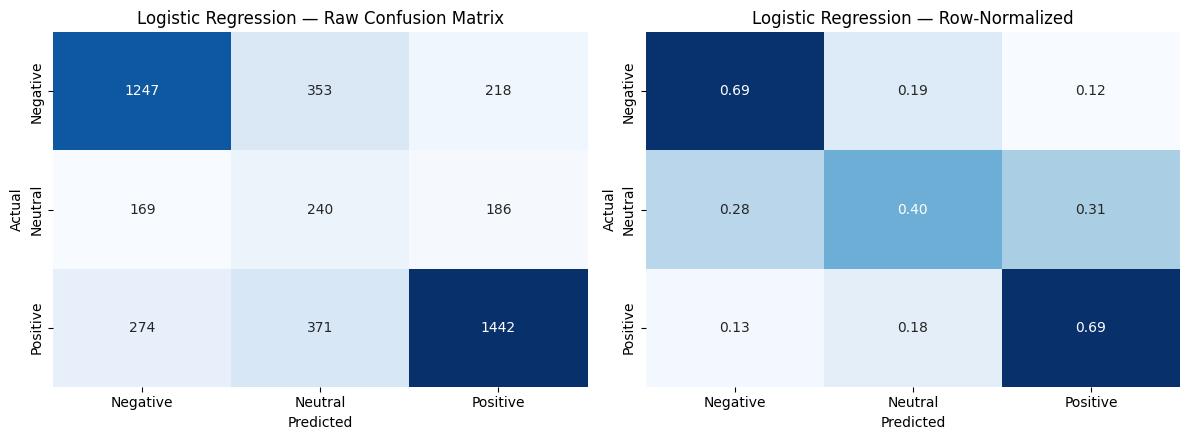

PosixPath('/content/artifacts/supervised_xai/logistic_regression_confusion_matrices.png')

In [14]:
# Final Logistic Regression: refit on train + validation, then evaluate once on test.
final_lr_pipeline = make_logistic_pipeline(best_lr_c, TFIDF_MAX_FEATURES)
start = time.perf_counter()
final_lr_pipeline.fit(train_validation_df["review_lem"], train_validation_df["target"])
lr_training_time = time.perf_counter() - start

start = time.perf_counter()
lr_test_pred = final_lr_pipeline.predict(test_df["review_lem"])
lr_test_prob = final_lr_pipeline.predict_proba(test_df["review_lem"])
lr_inference_time = time.perf_counter() - start

model_results.append(metrics_row(
    "Logistic Regression", f"TF-IDF (1–2 grams, {TFIDF_MAX_FEATURES:,} max features)",
    test_df["target"], lr_test_pred, lr_training_time, lr_inference_time,
))
model_predictions["Logistic Regression"] = lr_test_pred
model_probabilities["Logistic Regression"] = lr_test_prob
model_confidences["Logistic Regression"] = lr_test_prob.max(axis=1)
classification_reports["Logistic Regression"] = report_dataframe(test_df["target"], lr_test_pred)
training_times["Logistic Regression"] = lr_training_time
inference_times["Logistic Regression"] = lr_inference_time

display(classification_reports["Logistic Regression"].round(4))
save_confusion_matrices(
    test_df["target"], lr_test_pred, "Logistic Regression", "logistic_regression"
)


,precision,recall,f1-score,support
Negative,0.7164,0.7420,0.7290,1818.0000
Neutral,0.2625,0.2471,0.2545,595.0000
Positive,0.7589,0.7480,0.7534,2087.0000
accuracy,0.6793,0.6793,0.6793,0.6793
macro avg,0.5793,0.5790,0.5790,4500.0000
weighted avg,0.6761,0.6793,0.6776,4500.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


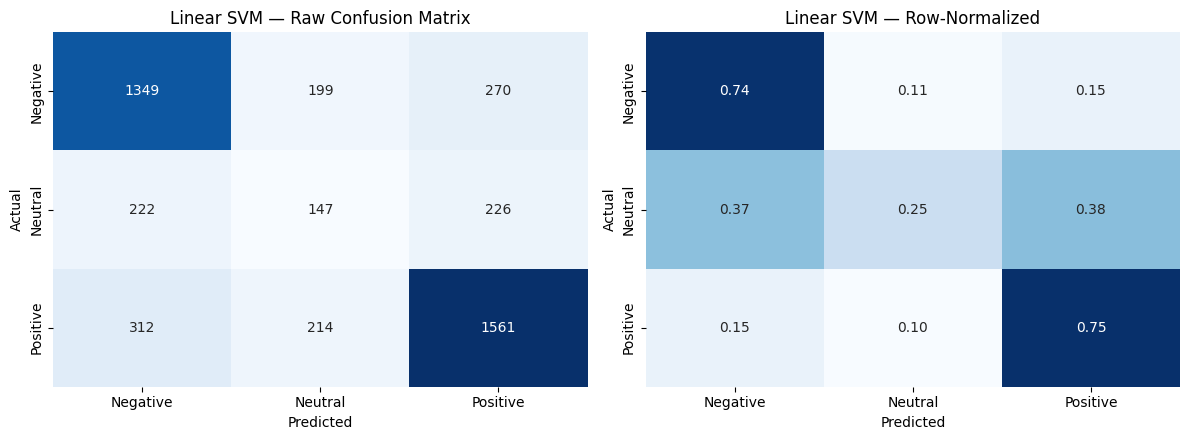

PosixPath('/content/artifacts/supervised_xai/linear_svm_confusion_matrices.png')

In [15]:
# Final Linear SVM: refit on train + validation, then evaluate once on test.
final_svm_pipeline = make_svm_pipeline(best_svm_c, TFIDF_MAX_FEATURES)
start = time.perf_counter()
final_svm_pipeline.fit(train_validation_df["review_lem"], train_validation_df["target"])
svm_training_time = time.perf_counter() - start

start = time.perf_counter()
svm_test_pred = final_svm_pipeline.predict(test_df["review_lem"])
svm_test_scores = final_svm_pipeline.decision_function(test_df["review_lem"])
svm_inference_time = time.perf_counter() - start

# Softmax converts decision scores into comparable confidence-like values.
# These are not calibrated probabilities and are used only for ranking errors.
svm_confidence_like = softmax(svm_test_scores, axis=1)

model_results.append(metrics_row(
    "Linear SVM", f"TF-IDF (1–2 grams, {TFIDF_MAX_FEATURES:,} max features)",
    test_df["target"], svm_test_pred, svm_training_time, svm_inference_time,
))
model_predictions["Linear SVM"] = svm_test_pred
model_probabilities["Linear SVM"] = svm_confidence_like
model_confidences["Linear SVM"] = svm_confidence_like.max(axis=1)
classification_reports["Linear SVM"] = report_dataframe(test_df["target"], svm_test_pred)
training_times["Linear SVM"] = svm_training_time
inference_times["Linear SVM"] = svm_inference_time

display(classification_reports["Linear SVM"].round(4))
save_confusion_matrices(test_df["target"], svm_test_pred, "Linear SVM", "linear_svm")


# 6. Deep-Learning Classification with a BiLSTM

The deep-learning model uses the non-lemmatized cleaned reviews so natural word forms and token order are retained.

The vocabulary is built from training text only. `<PAD>` has index 0 and `<UNK>` has index 1. Sequence length is the 95th percentile of training lengths, with a minimum of 20 and maximum of 200 tokens. The model contains:

1. an embedding layer;
2. one bidirectional LSTM layer;
3. concatenated final forward/backward states;
4. dropout;
5. a three-logit output layer.

Class-weighted cross-entropy addresses class imbalance. Early stopping monitors validation macro F1, and the test set is not used during training.


In [16]:
def tokenize_review(text: str) -> list[str]:
    return str(text).lower().split()


MAX_VOCAB_SIZE = 30_000
MIN_FREQUENCY = 2

training_tokens = [tokenize_review(text) for text in train_df["review_non_lem"]]
training_lengths = np.array([max(1, len(tokens)) for tokens in training_tokens])
SEQUENCE_LENGTH = int(np.percentile(training_lengths, 95))
SEQUENCE_LENGTH = max(20, min(SEQUENCE_LENGTH, 200))

word_counts = Counter(word for tokens in training_tokens for word in tokens)
frequent_words = [
    word for word, count in word_counts.most_common()
    if count >= MIN_FREQUENCY
]
frequent_words = frequent_words[: MAX_VOCAB_SIZE - 2]

vocabulary = {"<PAD>": 0, "<UNK>": 1}
vocabulary.update({word: index + 2 for index, word in enumerate(frequent_words)})

print("Training vocabulary size:", f"{len(vocabulary):,}")
print("95th-percentile/capped sequence length:", SEQUENCE_LENGTH)
print("Median training review length:", int(np.median(training_lengths)))


Training vocabulary size: 17,683
95th-percentile/capped sequence length: 92
Median training review length: 24


In [17]:
class ReviewSequenceDataset(Dataset):
    def __init__(self, texts, labels, vocabulary, max_length):
        self.labels = np.asarray(labels, dtype=np.int64)
        self.vocabulary = vocabulary
        self.max_length = max_length
        self.encoded_reviews = [self.encode(text) for text in texts]

    def encode(self, text):
        tokens = tokenize_review(text)
        token_ids = [self.vocabulary.get(token, 1) for token in tokens[: self.max_length]]
        if not token_ids:
            token_ids = [1]
        length = len(token_ids)
        token_ids.extend([0] * (self.max_length - length))
        return np.asarray(token_ids, dtype=np.int64), length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        token_ids, length = self.encoded_reviews[index]
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long),
        )


train_dataset = ReviewSequenceDataset(
    train_df["review_non_lem"].tolist(), train_df["target"].tolist(),
    vocabulary, SEQUENCE_LENGTH,
)
validation_dataset = ReviewSequenceDataset(
    validation_df["review_non_lem"].tolist(), validation_df["target"].tolist(),
    vocabulary, SEQUENCE_LENGTH,
)
test_dataset = ReviewSequenceDataset(
    test_df["review_non_lem"].tolist(), test_df["target"].tolist(),
    vocabulary, SEQUENCE_LENGTH,
)

BATCH_SIZE = 128 if DEVICE.type == "cuda" else 64
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, generator=train_generator,
)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print("Batch size:", BATCH_SIZE)
print("Train/validation/test batches:", len(train_loader), len(validation_loader), len(test_loader))


Batch size: 64
Train/validation/test batches: 329 71 71


In [18]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocabulary_size,
        embedding_dimension=128,
        hidden_dimension=128,
        output_dimension=3,
        dropout_probability=0.30,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocabulary_size, embedding_dimension, padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dimension,
            hidden_size=hidden_dimension,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout_probability)
        self.output = nn.Linear(hidden_dimension * 2, output_dimension)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden_state, _) = self.lstm(packed)
        forward_final = hidden_state[-2]
        backward_final = hidden_state[-1]
        combined = torch.cat((forward_final, backward_final), dim=1)
        return self.output(self.dropout(combined))


bilstm_model = BiLSTMClassifier(vocabulary_size=len(vocabulary)).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in bilstm_model.parameters())
trainable_parameter_count = sum(
    parameter.numel() for parameter in bilstm_model.parameters() if parameter.requires_grad
)

print(bilstm_model)
print(f"Total parameters: {parameter_count:,}")
print(f"Trainable parameters: {trainable_parameter_count:,}")


BiLSTMClassifier(
  (embedding): Embedding(17683, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=256, out_features=3, bias=True)
)
Total parameters: 2,528,387
Trainable parameters: 2,528,387


In [19]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(LABELS),
    y=train_df["target"].to_numpy(),
)
class_weights = torch.tensor(class_weight_values, dtype=torch.float32, device=DEVICE)

loss_function = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)
EARLY_STOPPING_PATIENCE = 2

print("Training class weights:", dict(zip(CLASS_NAMES, class_weight_values.round(4))))


Training class weights: {'Negative': np.float64(0.8254), 'Neutral': np.float64(2.5198), 'Positive': np.float64(0.7186)}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
def run_bilstm_epoch(model, loader, loss_function, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.set_grad_enabled(is_training):
        for token_ids, lengths, targets in loader:
            token_ids = token_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            targets = targets.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            logits = model(token_ids, lengths)
            loss = loss_function(logits, targets)

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(targets)
            all_predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_targets.extend(targets.detach().cpu().numpy())

    average_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(
        all_targets, all_predictions, labels=LABELS, average="macro", zero_division=0
    )
    return average_loss, macro_f1


def predict_bilstm(model, loader):
    model.eval()
    probabilities = []
    targets = []
    with torch.no_grad():
        for token_ids, lengths, batch_targets in loader:
            token_ids = token_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            logits = model(token_ids, lengths)
            probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
            targets.extend(batch_targets.numpy())
    probabilities = np.vstack(probabilities)
    predictions = probabilities.argmax(axis=1)
    return np.asarray(targets), predictions, probabilities


In [21]:
training_history = {
    "epoch": [],
    "train_loss": [],
    "validation_loss": [],
    "train_macro_f1": [],
    "validation_macro_f1": [],
}

best_validation_f1 = -np.inf
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

start = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_macro_f1 = run_bilstm_epoch(
        bilstm_model, train_loader, loss_function, optimizer
    )
    validation_loss, validation_macro_f1 = run_bilstm_epoch(
        bilstm_model, validation_loader, loss_function
    )

    training_history["epoch"].append(epoch)
    training_history["train_loss"].append(train_loss)
    training_history["validation_loss"].append(validation_loss)
    training_history["train_macro_f1"].append(train_macro_f1)
    training_history["validation_macro_f1"].append(validation_macro_f1)

    print(
        f"Epoch {epoch:02d} | train loss={train_loss:.4f} | val loss={validation_loss:.4f} "
        f"| train macro F1={train_macro_f1:.4f} | val macro F1={validation_macro_f1:.4f}"
    )

    if validation_macro_f1 > best_validation_f1 + 1e-4:
        best_validation_f1 = validation_macro_f1
        best_epoch = epoch
        best_model_state = deepcopy({
            key: value.detach().cpu() for key, value in bilstm_model.state_dict().items()
        })
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after epoch {epoch}; best epoch was {best_epoch}.")
        break

bilstm_training_time = time.perf_counter() - start
if best_model_state is None:
    raise RuntimeError("BiLSTM training did not produce a valid model state.")

bilstm_model.load_state_dict(best_model_state)
bilstm_model.to(DEVICE)
print(f"Restored best BiLSTM from epoch {best_epoch} with validation macro F1={best_validation_f1:.4f}")
print(f"BiLSTM training time: {bilstm_training_time:.2f} seconds")


Epoch 01 | train loss=1.0251 | val loss=0.9699 | train macro F1=0.4555 | val macro F1=0.5022


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 02 | train loss=0.8707 | val loss=0.9383 | train macro F1=0.5825 | val macro F1=0.5213


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 03 | train loss=0.7264 | val loss=1.0031 | train macro F1=0.6572 | val macro F1=0.5366


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 06 | train loss=0.2180 | val loss=1.6235 | train macro F1=0.9057 | val macro F1=0.5306


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 07 | train loss=0.1327 | val loss=1.9227 | train macro F1=0.9460 | val macro F1=0.5298
Early stopping after epoch 7; best epoch was 5.
Restored best BiLSTM from epoch 5 with validation macro F1=0.5435
BiLSTM training time: 851.56 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,epoch,train_loss,validation_loss,train_macro_f1,validation_macro_f1
0,1,1.0251,0.9699,0.4555,0.5022
1,2,0.8707,0.9383,0.5825,0.5213
2,3,0.7264,1.0031,0.6572,0.5366
3,4,0.5497,1.1322,0.7446,0.5322
4,5,0.3631,1.3060,0.8370,0.5435
5,6,0.2180,1.6235,0.9057,0.5306
6,7,0.1327,1.9227,0.9460,0.5298


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


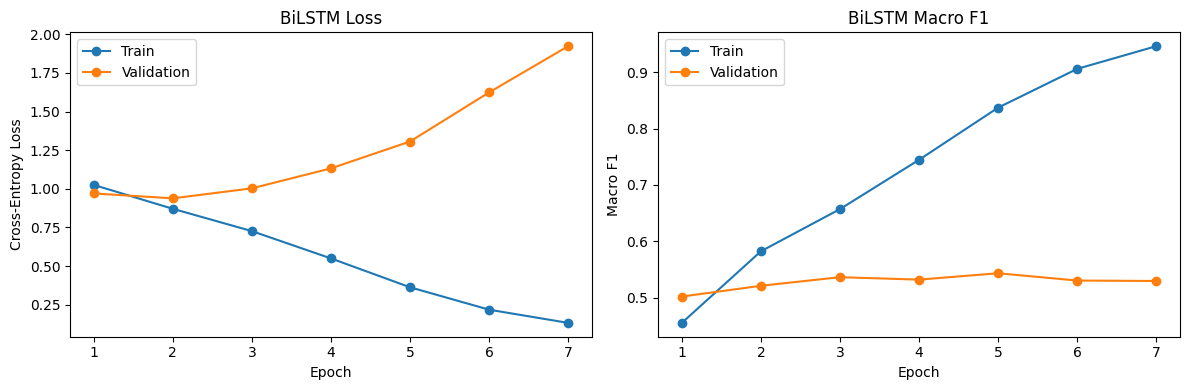

In [22]:
history_df = pd.DataFrame(training_history)
display(history_df.round(4))

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="Validation")
axes[0].set_title("BiLSTM Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train")
axes[1].plot(history_df["epoch"], history_df["validation_macro_f1"], marker="o", label="Validation")
axes[1].set_title("BiLSTM Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()

figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "bilstm_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()


,precision,recall,f1-score,support
Negative,0.6934,0.6557,0.6740,1818.0000
Neutral,0.1986,0.2958,0.2377,595.0000
Positive,0.7377,0.6699,0.7022,2087.0000
accuracy,0.6147,0.6147,0.6147,0.6147
macro avg,0.5433,0.5404,0.5380,4500.0000
weighted avg,0.6486,0.6147,0.6294,4500.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


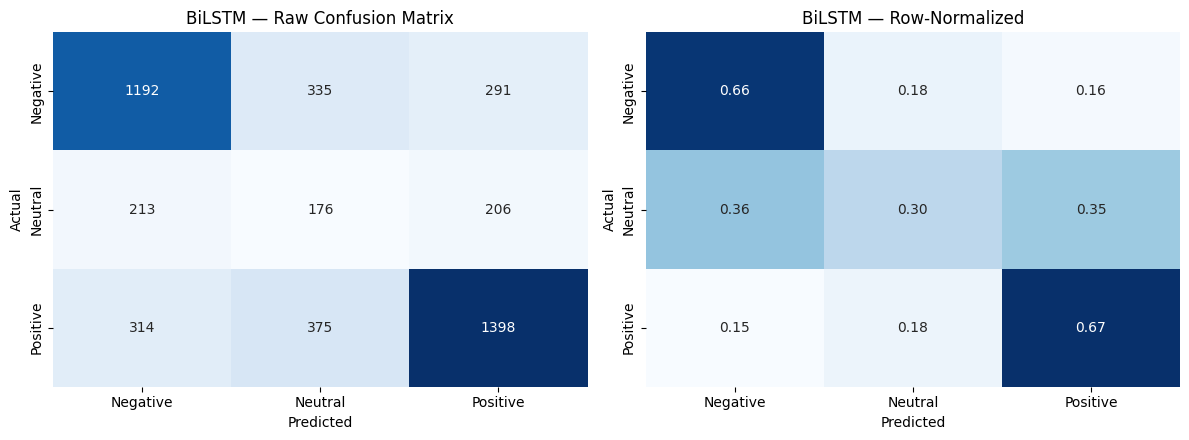

PosixPath('/content/artifacts/supervised_xai/bilstm_confusion_matrices.png')

In [23]:
start = time.perf_counter()
bilstm_test_targets, bilstm_test_pred, bilstm_test_prob = predict_bilstm(
    bilstm_model, test_loader
)
bilstm_inference_time = time.perf_counter() - start

assert np.array_equal(bilstm_test_targets, test_df["target"].to_numpy())

model_results.append(metrics_row(
    "BiLSTM", "Train-only vocabulary + non-lemmatized token sequences",
    test_df["target"], bilstm_test_pred, bilstm_training_time, bilstm_inference_time,
))
model_predictions["BiLSTM"] = bilstm_test_pred
model_probabilities["BiLSTM"] = bilstm_test_prob
model_confidences["BiLSTM"] = bilstm_test_prob.max(axis=1)
classification_reports["BiLSTM"] = report_dataframe(test_df["target"], bilstm_test_pred)
training_times["BiLSTM"] = bilstm_training_time
inference_times["BiLSTM"] = bilstm_inference_time

display(classification_reports["BiLSTM"].round(4))
save_confusion_matrices(test_df["target"], bilstm_test_pred, "BiLSTM", "bilstm")


# 7. Model Comparison

Macro F1 is the primary comparison metric because it gives equal importance to Negative, Neutral, and Positive reviews. Accuracy and weighted F1 are also reported, but they can be dominated by the largest class.

Training-time comparisons should be interpreted carefully: traditional models and neural networks have different optimization processes, and hardware strongly affects the BiLSTM runtime.


,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Inference Time (s)
0,Logistic Regression,"TF-IDF (1–2 grams, 10,000 max features)",0.6509,0.5893,0.5934,0.5840,0.6680,6.0099,0.5231
1,Linear SVM,"TF-IDF (1–2 grams, 10,000 max features)",0.6793,0.5793,0.5790,0.5790,0.6776,5.5888,0.5420
2,BiLSTM,Train-only vocabulary + non-lemmatized token sequences,0.6147,0.5433,0.5404,0.5380,0.6294,851.5633,5.3677
3,Dummy Majority,No text representation,0.4638,0.1546,0.3333,0.2112,0.2939,0.0023,0.0015


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Highest test macro F1: Logistic Regression (0.5840)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


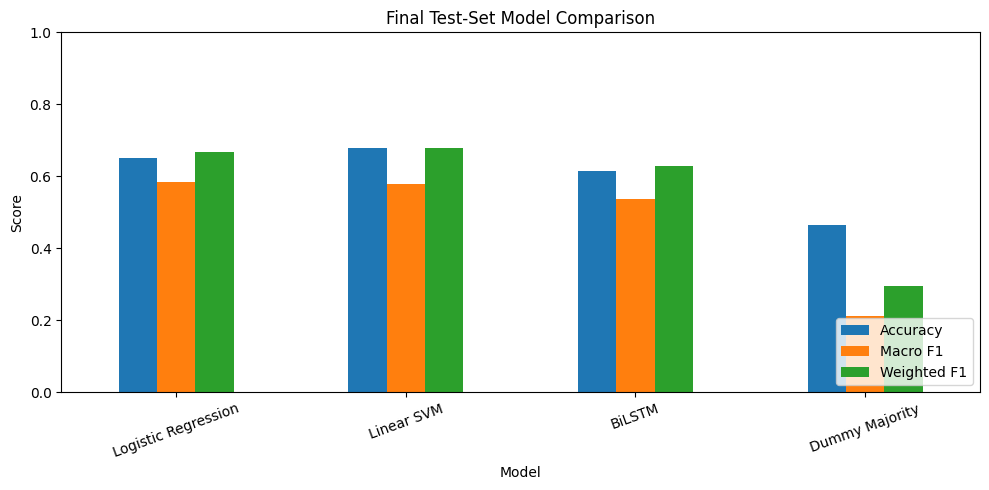

In [24]:
metrics_comparison = (
    pd.DataFrame(model_results)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)
metrics_comparison.to_csv(ARTIFACT_DIR / "metrics_comparison.csv", index=False)
display(metrics_comparison.round(4))

best_model_name = metrics_comparison.loc[0, "Model"]
best_macro_f1 = metrics_comparison.loc[0, "Macro F1"]
print(f"Highest test macro F1: {best_model_name} ({best_macro_f1:.4f})")

plot_data = metrics_comparison.set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]]
axis = plot_data.plot(kind="bar", figsize=(10, 5))
axis.set_ylim(0, 1)
axis.set_ylabel("Score")
axis.set_title("Final Test-Set Model Comparison")
axis.tick_params(axis="x", rotation=20)
axis.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# 8. Explainable AI

The final Logistic Regression pipeline is used for XAI because it provides multiclass probabilities and has a direct, interpretable connection between TF-IDF features and class coefficients.

Three complementary views are produced:

- **Logistic Regression coefficients:** stable global feature directions;
- **LIME:** local explanations for individual predictions;
- **SHAP:** global and local contribution summaries on a small stratified sample.

These methods explain model behavior. They do not establish medical causality, clinical effectiveness, or treatment safety.


## 8.1 Global Logistic Regression Coefficients

For each class, positive coefficients increase that class's logit, while negative coefficients move the prediction away from it. Correlated words and phrases can divide importance across multiple features, so individual coefficients should be interpreted in context.


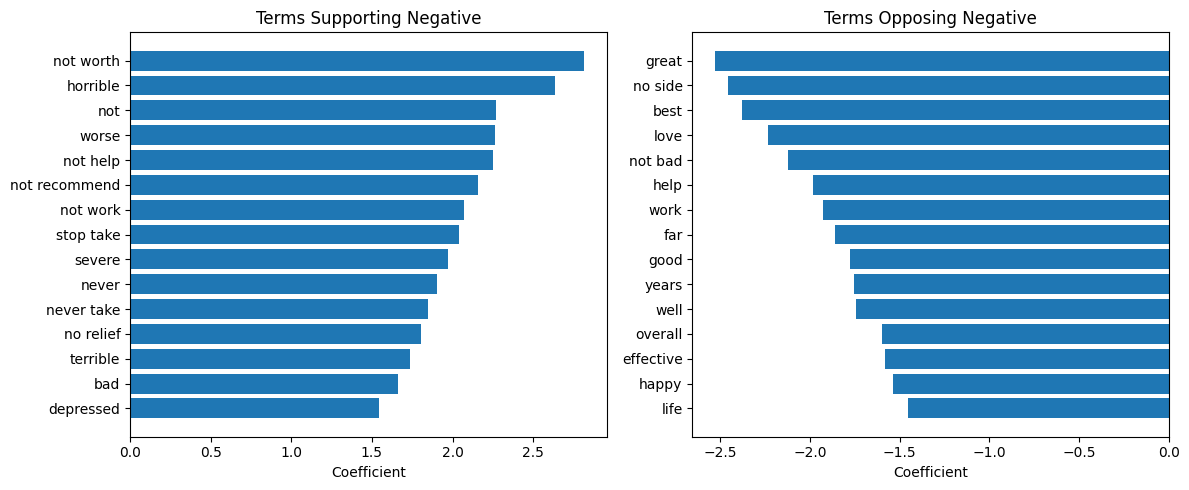

,Term,Coefficient,Direction
0,not worth,2.8166,Supports class
1,horrible,2.6353,Supports class
2,not,2.2704,Supports class
3,worse,2.2628,Supports class
4,not help,2.2493,Supports class
5,not recommend,2.1560,Supports class
6,not work,2.0700,Supports class
7,stop take,2.0419,Supports class
8,severe,1.9746,Supports class
9,never,1.9039,Supports class


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


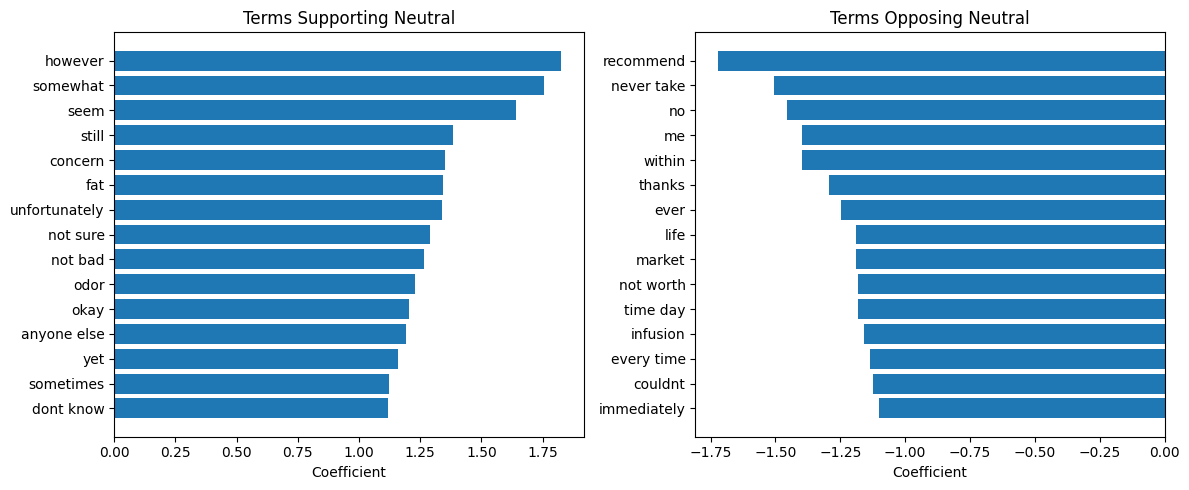

,Term,Coefficient,Direction
0,however,1.8267,Supports class
1,somewhat,1.7564,Supports class
2,seem,1.6397,Supports class
3,still,1.3860,Supports class
4,concern,1.3516,Supports class
5,fat,1.3444,Supports class
6,unfortunately,1.3403,Supports class
7,not sure,1.2891,Supports class
8,not bad,1.2655,Supports class
9,odor,1.2280,Supports class


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


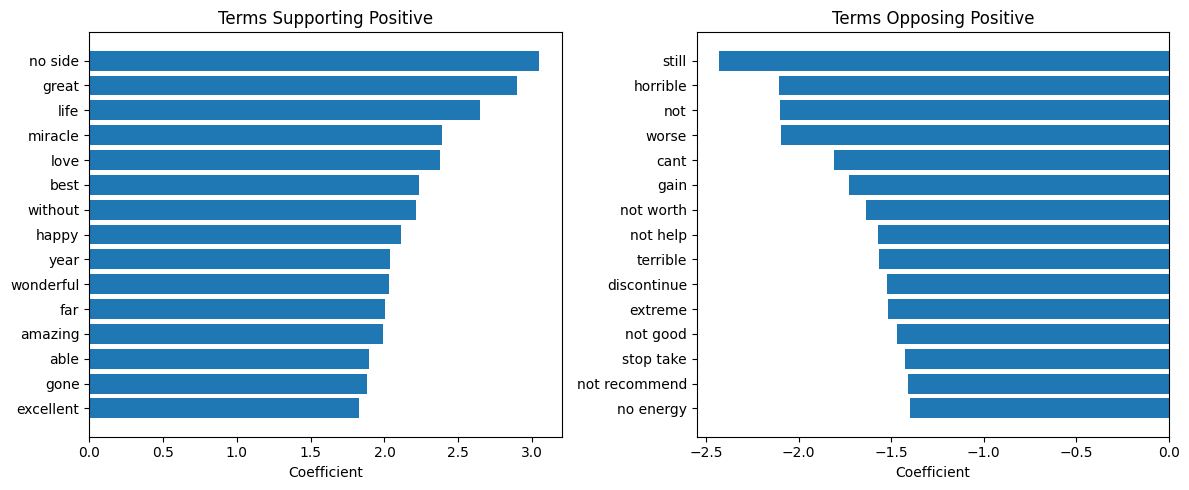

,Term,Coefficient,Direction
0,no side,3.0469,Supports class
1,great,2.8990,Supports class
2,life,2.6467,Supports class
3,miracle,2.3888,Supports class
4,love,2.3730,Supports class
5,best,2.2369,Supports class
6,without,2.2120,Supports class
7,happy,2.1153,Supports class
8,year,2.0402,Supports class
9,wonderful,2.0301,Supports class


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
lr_vectorizer = final_lr_pipeline.named_steps["tfidf"]
lr_classifier = final_lr_pipeline.named_steps["classifier"]
feature_names = np.asarray(lr_vectorizer.get_feature_names_out())

coefficient_tables = {}
for class_index, class_name in enumerate(CLASS_NAMES):
    coefficients = lr_classifier.coef_[class_index]
    supporting_indices = np.argsort(coefficients)[-15:][::-1]
    opposing_indices = np.argsort(coefficients)[:15]

    supporting = pd.DataFrame({
        "Term": feature_names[supporting_indices],
        "Coefficient": coefficients[supporting_indices],
        "Direction": "Supports class",
    })
    opposing = pd.DataFrame({
        "Term": feature_names[opposing_indices],
        "Coefficient": coefficients[opposing_indices],
        "Direction": "Opposes class",
    })
    coefficient_tables[class_name] = pd.concat([supporting, opposing], ignore_index=True)
    coefficient_tables[class_name].to_csv(
        ARTIFACT_DIR / f"logistic_coefficients_{class_name.lower()}.csv", index=False
    )

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].barh(supporting["Term"][::-1], supporting["Coefficient"][::-1])
    axes[0].set_title(f"Terms Supporting {class_name}")
    axes[0].set_xlabel("Coefficient")

    axes[1].barh(opposing["Term"][::-1], opposing["Coefficient"][::-1])
    axes[1].set_title(f"Terms Opposing {class_name}")
    axes[1].set_xlabel("Coefficient")

    figure.tight_layout()
    figure.savefig(
        ARTIFACT_DIR / f"logistic_coefficients_{class_name.lower()}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    display(coefficient_tables[class_name].round(4))


## 8.2 LIME Local Explanations

LIME perturbs one review around the selected prediction and fits a simple local surrogate model. The contribution weights are local to that review and should not automatically be generalized to the entire dataset.


Example: correct_negative
Selection note: Correctly predicted high-confidence Negative review.
True class: Negative
Predicted class: Negative
Probabilities: {'Negative': np.float64(0.9658), 'Neutral': np.float64(0.023), 'Positive': np.float64(0.0112)}
Original non-lemmatized review:
not take med. severe reaction resulting severe joint pain swelling wrists hands. hands swollen hurt horribly. dose called doctor told stop immediately. side effects severe me!
Model input (lemmatized):
not take med. severe reaction result severe joint pain swell wrist hands. hand swollen hurt horribly. dose call doctor tell stop immediately. side effect severe me!


/usr/local/lib/python3.12/dist-packages/lime/explanation.py:251: ResourceWarning: unclosed file <_io.TextIOWrapper name='/usr/local/lib/python3.12/dist-packages/lime/bundle.js' mode='r' encoding='utf8'>
  encoding="utf8").read()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Term / condition,LIME contribution
0,call,0.0473
1,severe,0.0416
2,not,0.0292
3,swollen,0.0250
4,stop,0.0245
5,tell,0.0221
6,reaction,0.0203
7,immediately,0.0188
8,doctor,0.0185
9,swell,0.0183


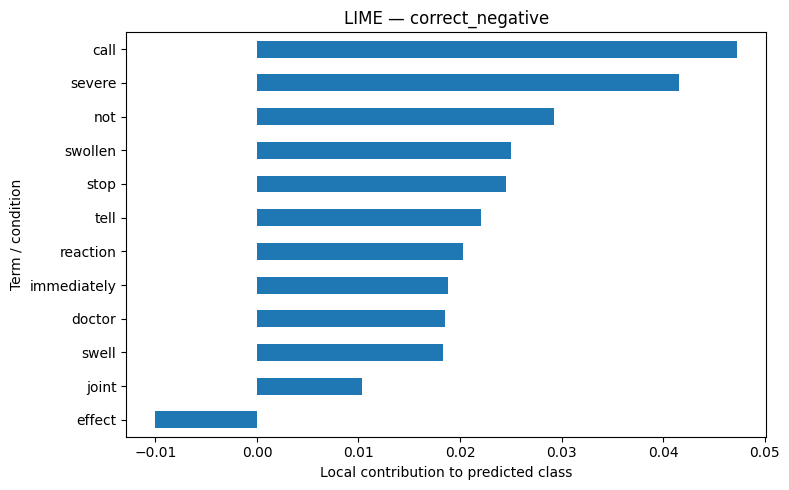

Example: correct_positive
Selection note: Correctly predicted high-confidence Positive review.
True class: Positive
Predicted class: Positive
Probabilities: {'Negative': np.float64(0.0094), 'Neutral': np.float64(0.0236), 'Positive': np.float64(0.967)}
Original non-lemmatized review:
worked well cholesterol levels. ive taken medication years great results no side effects.
Model input (lemmatized):
work well cholesterol levels. ive take medication year great result no side effects.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/lime/explanation.py:251: ResourceWarning: unclosed file <_io.TextIOWrapper name='/usr/local/lib/python3.12/dist-packages/lime/bundle.js' mode='r' encoding='utf8'>
  encoding="utf8").read()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Term / condition,LIME contribution
0,no,0.0962
1,great,0.0859
2,year,0.0608
3,side,0.0584
4,work,0.0429
5,well,0.0392
6,result,0.0325
7,cholesterol,0.0250
8,levels,-0.0205
9,ive,-0.0076


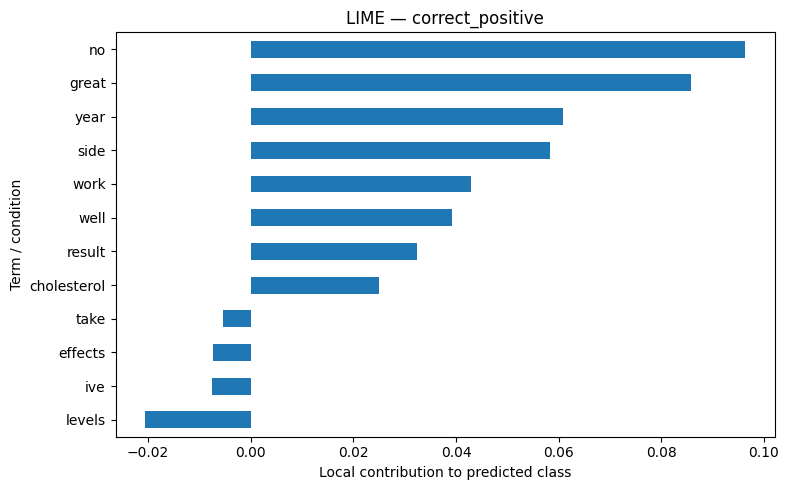

Example: misclassified_or_low_confidence
Selection note: High-confidence misclassification.
True class: Neutral
Predicted class: Negative
Probabilities: {'Negative': np.float64(0.9315), 'Neutral': np.float64(0.0416), 'Positive': np.float64(0.0269)}
Original non-lemmatized review:
admitted hospital severe kidney infection. started vanco immediately going septic. round vanco developed ringing ears severe dizziness. returning home dizziness became incapacitating. unable walk drive even bathe myself. later learned dr. vanco damaged inner ear causing dizziness. endure months physical therapy try strengthen gait. least alive. could worse.
Model input (lemmatized):
admit hospital severe kidney infection. start vanco immediately go septic. round vanco develop ring ear severe dizziness. return home dizziness become incapacitating. unable walk drive even bathe myself. later learn dr. vanco damage inner ear cause dizziness. endure month physical therapy try strengthen gait. least alive. could wor

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/lime/explanation.py:251: ResourceWarning: unclosed file <_io.TextIOWrapper name='/usr/local/lib/python3.12/dist-packages/lime/bundle.js' mode='r' encoding='utf8'>
  encoding="utf8").read()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Term / condition,LIME contribution
0,severe,0.0790
1,worse,0.0778
2,hospital,0.0491
3,develop,0.0420
4,dizziness,0.0356
5,cause,0.0287
6,unable,0.0282
7,damage,0.0260
8,least,-0.0250
9,alive,-0.0200


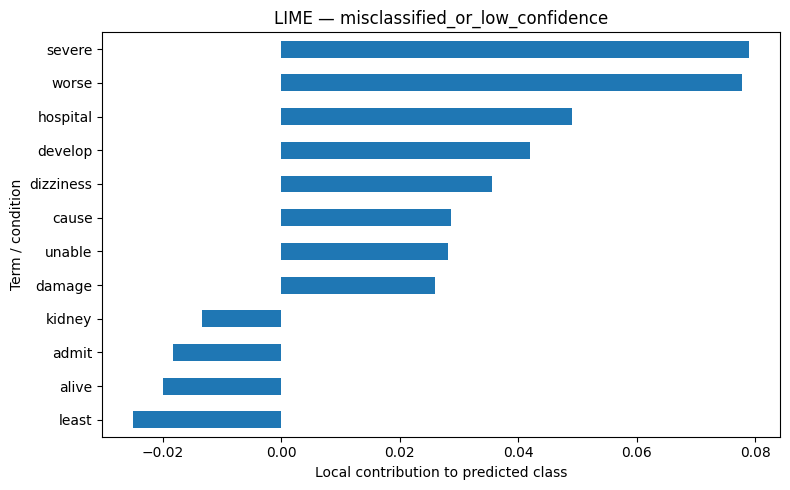

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Example,Selection note,row_id,True class,Predicted class,Confidence,HTML file
0,correct_negative,Correctly predicted high-confidence Negative review.,213881,Negative,Negative,0.9658,lime_correct_negative.html
1,correct_positive,Correctly predicted high-confidence Positive review.,248553,Positive,Positive,0.9670,lime_correct_positive.html
2,misclassified_or_low_confidence,High-confidence misclassification.,187023,Neutral,Negative,0.9315,lime_misclassified_or_low_confidence.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(
    class_names=CLASS_NAMES,
    random_state=SEED,
)
LIME_NUM_SAMPLES = 150 if SMOKE_TEST else 1_000

lr_true = test_df["target"].to_numpy()
lr_pred = np.asarray(lr_test_pred)
lr_confidence = lr_test_prob.max(axis=1)


def best_position(mask, confidence, highest=True, excluded=None):
    excluded = set() if excluded is None else set(excluded)
    candidates = [position for position in np.where(mask)[0] if position not in excluded]
    if not candidates:
        return None
    return sorted(
        candidates,
        key=lambda position: confidence[position],
        reverse=highest,
    )[0]


selected_positions = []
used_positions = set()

# Preferred case 1: a correctly predicted high-confidence Negative review.
negative_position = best_position(
    (lr_true == 0) & (lr_pred == 0), lr_confidence, highest=True
)
negative_note = "Correctly predicted high-confidence Negative review."
if negative_position is None:
    negative_position = best_position(lr_true == 0, lr_confidence, highest=True)
    negative_note = (
        "No correctly predicted Negative review was available; this is the highest-confidence "
        "actual Negative fallback and should be discussed as a model limitation."
    )
if negative_position is None:
    negative_position = best_position(np.ones(len(test_df), dtype=bool), lr_confidence, highest=True)
    negative_note = "No Negative test review was available; a transparent fallback was used."
selected_positions.append(("correct_negative", negative_position, negative_note))
used_positions.add(negative_position)

# Preferred case 2: a correctly predicted high-confidence Positive review.
positive_position = best_position(
    (lr_true == 2) & (lr_pred == 2), lr_confidence, highest=True, excluded=used_positions
)
positive_note = "Correctly predicted high-confidence Positive review."
if positive_position is None:
    positive_position = best_position(
        lr_true == 2, lr_confidence, highest=True, excluded=used_positions
    )
    positive_note = (
        "No correctly predicted Positive review was available; this is the highest-confidence "
        "actual Positive fallback and should be discussed as a model limitation."
    )
if positive_position is None:
    positive_position = best_position(
        np.ones(len(test_df), dtype=bool), lr_confidence, highest=True, excluded=used_positions
    )
    positive_note = "No Positive test review was available; a transparent fallback was used."
selected_positions.append(("correct_positive", positive_position, positive_note))
used_positions.add(positive_position)

# Case 3: a high-confidence error; if none exists, use the lowest-confidence remaining review.
error_position = best_position(
    lr_true != lr_pred, lr_confidence, highest=True, excluded=used_positions
)
error_note = "High-confidence misclassification."
if error_position is None:
    error_position = best_position(
        np.ones(len(test_df), dtype=bool), lr_confidence, highest=False, excluded=used_positions
    )
    error_note = "No Logistic Regression test error was available; lowest-confidence fallback used."
if error_position is None:
    error_position = best_position(
        np.ones(len(test_df), dtype=bool), lr_confidence, highest=False
    )
selected_positions.append(("misclassified_or_low_confidence", error_position, error_note))

lime_summary_rows = []
for explanation_name, position, selection_note in selected_positions:
    row = test_df.iloc[position]
    predicted_class = int(lr_pred[position])
    explanation = lime_explainer.explain_instance(
        row["review_lem"],
        final_lr_pipeline.predict_proba,
        labels=[predicted_class],
        num_features=12,
        num_samples=LIME_NUM_SAMPLES,
    )

    contribution_df = pd.DataFrame(
        explanation.as_list(label=predicted_class),
        columns=["Term / condition", "LIME contribution"],
    )
    html_path = ARTIFACT_DIR / f"lime_{explanation_name}.html"
    explanation.save_to_file(str(html_path))

    print("=" * 90)
    print("Example:", explanation_name)
    print("Selection note:", selection_note)
    print("True class:", CLASS_NAMES[int(row["target"])])
    print("Predicted class:", CLASS_NAMES[predicted_class])
    print("Probabilities:", dict(zip(CLASS_NAMES, lr_test_prob[position].round(4))))
    print("Original non-lemmatized review:")
    print(row["review_non_lem"])
    print("Model input (lemmatized):")
    print(row["review_lem"])
    display(contribution_df.round(4))

    axis = contribution_df.sort_values("LIME contribution").plot(
        kind="barh", x="Term / condition", y="LIME contribution",
        legend=False, figsize=(8, 5),
    )
    axis.set_title(f"LIME — {explanation_name}")
    axis.set_xlabel("Local contribution to predicted class")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / f"lime_{explanation_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

    lime_summary_rows.append({
        "Example": explanation_name,
        "Selection note": selection_note,
        "row_id": int(row["row_id"]),
        "True class": CLASS_NAMES[int(row["target"])],
        "Predicted class": CLASS_NAMES[predicted_class],
        "Confidence": float(lr_confidence[position]),
        "HTML file": html_path.name,
    })

lime_summary = pd.DataFrame(lime_summary_rows)
lime_summary.to_csv(ARTIFACT_DIR / "lime_examples_summary.csv", index=False)
display(lime_summary.round(4))


## 8.3 SHAP Global and Local Explanations

SHAP is applied only to a small stratified sample because the TF-IDF feature space is high-dimensional. Mean absolute SHAP values summarize feature influence for each class, and one local bar chart shows the strongest contributions for a selected review.

If the installed SHAP/scikit-learn combination is incompatible, the error is saved and displayed transparently. Coefficient analysis and LIME remain complete.


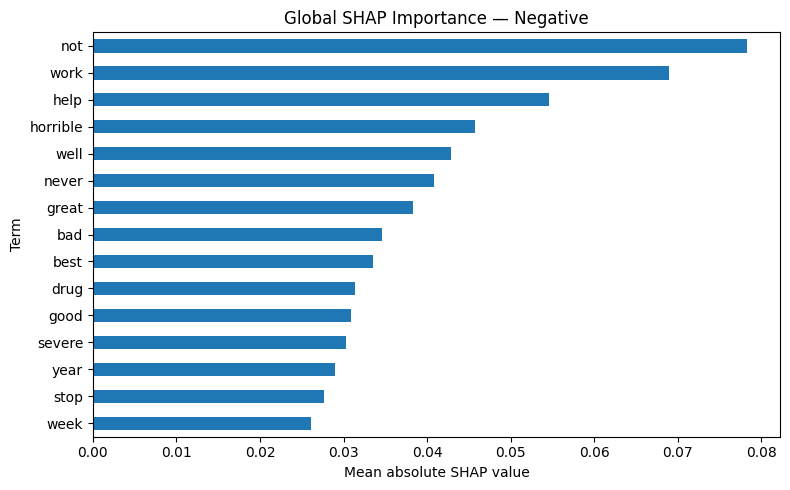

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


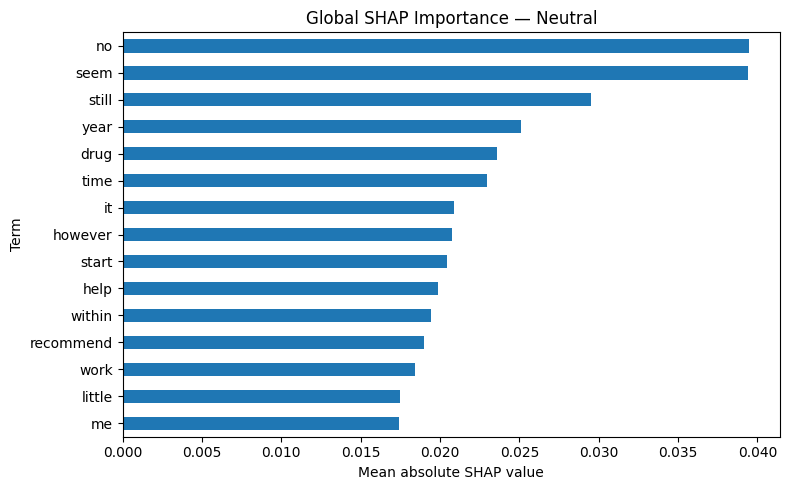

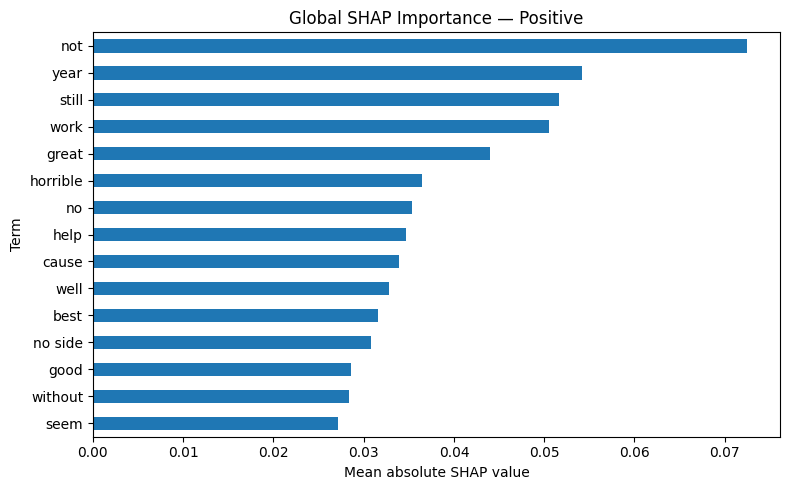

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


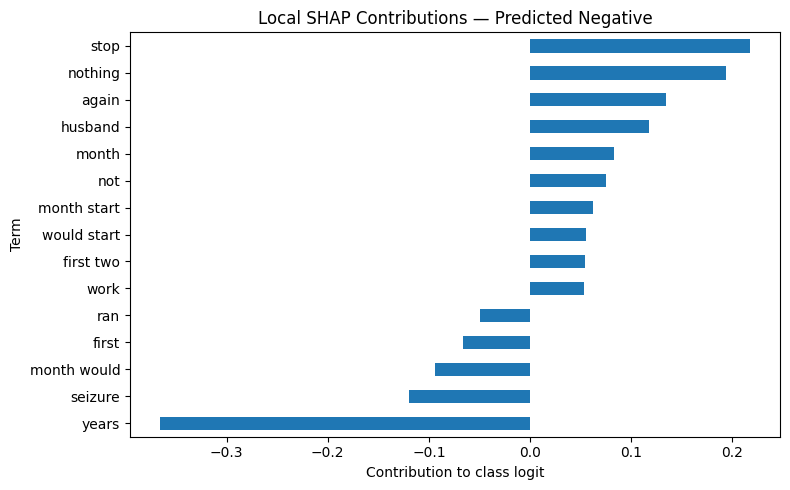

SHAP local review:
husband seizures years. kepra first two years. seizures not stop. carbamazepine seizues stopped every months would start vommit day. every test ran found nothing. visits getting tedious saline bag antinaseau drip. lamotrigine month starting vommit again.
SHAP local probabilities: {'Negative': np.float64(0.4524), 'Neutral': np.float64(0.2673), 'Positive': np.float64(0.2803)}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Term,SHAP contribution
0,years,-0.36630
1,stop,0.21794
2,nothing,0.19335
3,again,0.13404
4,seizure,-0.11947
5,husband,0.11805
6,month would,-0.09388
7,month,0.08301
8,not,0.07502
9,first,-0.06583


SHAP status: PASS


In [27]:
import shap

SHAP_BACKGROUND_SIZE = 30 if SMOKE_TEST else 100
SHAP_EXPLAIN_SIZE = 30 if SMOKE_TEST else 100
SHAP_STATUS = "NOT_RUN"
SHAP_ERROR = None


def small_stratified_subset(dataframe, requested_size):
    requested_size = min(requested_size, len(dataframe))
    if requested_size == len(dataframe):
        return dataframe.copy().reset_index(drop=True)
    subset, _ = train_test_split(
        dataframe,
        train_size=requested_size,
        stratify=dataframe["target"],
        random_state=SEED,
    )
    return subset.reset_index(drop=True)


def normalize_multiclass_shap(raw_values, class_count):
    """Convert common SHAP multiclass outputs to a list of [samples, features] arrays."""
    if isinstance(raw_values, list):
        values_by_class = [np.asarray(values) for values in raw_values]
    else:
        values = np.asarray(raw_values)
        if values.ndim == 3 and values.shape[-1] == class_count:
            values_by_class = [values[:, :, class_index] for class_index in range(class_count)]
        elif values.ndim == 3 and values.shape[0] == class_count:
            values_by_class = [values[class_index] for class_index in range(class_count)]
        elif values.ndim == 2 and class_count == 2:
            values_by_class = [-values, values]
        else:
            raise ValueError(f"Unsupported multiclass SHAP shape: {values.shape}")

    if len(values_by_class) != class_count:
        raise ValueError(
            f"Expected {class_count} class explanations but received {len(values_by_class)}."
        )
    return values_by_class


try:
    shap_background_df = small_stratified_subset(train_df, SHAP_BACKGROUND_SIZE)
    shap_test_df = small_stratified_subset(test_df, SHAP_EXPLAIN_SIZE)

    shap_background_matrix = lr_vectorizer.transform(shap_background_df["review_lem"])
    shap_test_matrix = lr_vectorizer.transform(shap_test_df["review_lem"])

    shap_explainer = shap.LinearExplainer(lr_classifier, shap_background_matrix)
    try:
        shap_raw = shap_explainer.shap_values(shap_test_matrix)
    except AttributeError:
        shap_raw = shap_explainer(shap_test_matrix).values

    shap_values_by_class = normalize_multiclass_shap(shap_raw, len(CLASS_NAMES))

    for class_index, class_name in enumerate(CLASS_NAMES):
        mean_absolute_values = np.abs(shap_values_by_class[class_index]).mean(axis=0)
        top_indices = np.argsort(mean_absolute_values)[-15:][::-1]
        shap_global_df = pd.DataFrame({
            "Term": feature_names[top_indices],
            "Mean absolute SHAP": mean_absolute_values[top_indices],
        })
        shap_global_df.to_csv(
            ARTIFACT_DIR / f"shap_global_{class_name.lower()}.csv", index=False
        )

        axis = shap_global_df.sort_values("Mean absolute SHAP").plot(
            kind="barh", x="Term", y="Mean absolute SHAP",
            legend=False, figsize=(8, 5),
        )
        axis.set_title(f"Global SHAP Importance — {class_name}")
        axis.set_xlabel("Mean absolute SHAP value")
        plt.tight_layout()
        plt.savefig(
            ARTIFACT_DIR / f"shap_global_{class_name.lower()}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    local_position = 0
    local_probabilities = final_lr_pipeline.predict_proba(
        [shap_test_df.iloc[local_position]["review_lem"]]
    )[0]
    local_class = int(np.argmax(local_probabilities))
    local_contributions = shap_values_by_class[local_class][local_position]
    local_top_indices = np.argsort(np.abs(local_contributions))[-15:][::-1]
    shap_local_df = pd.DataFrame({
        "Term": feature_names[local_top_indices],
        "SHAP contribution": local_contributions[local_top_indices],
    })
    shap_local_df.to_csv(ARTIFACT_DIR / "shap_local_example.csv", index=False)

    axis = shap_local_df.sort_values("SHAP contribution").plot(
        kind="barh", x="Term", y="SHAP contribution",
        legend=False, figsize=(8, 5),
    )
    axis.set_title(f"Local SHAP Contributions — Predicted {CLASS_NAMES[local_class]}")
    axis.set_xlabel("Contribution to class logit")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "shap_local_example.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("SHAP local review:")
    print(shap_test_df.iloc[local_position]["review_non_lem"])
    print("SHAP local probabilities:", dict(zip(CLASS_NAMES, local_probabilities.round(4))))
    display(shap_local_df.round(5))

    SHAP_STATUS = "PASS"
except Exception as error:
    SHAP_STATUS = "NON_FATAL_FALLBACK"
    SHAP_ERROR = f"{type(error).__name__}: {error}"
    error_message = (
        "SHAP could not be completed in this environment. "
        "The coefficient and LIME explanations above remain complete.\n"
        f"Actionable error: {SHAP_ERROR}"
    )
    print(error_message)
    (ARTIFACT_DIR / "shap_status.txt").write_text(error_message, encoding="utf-8")

print("SHAP status:", SHAP_STATUS)


# 9. Error Analysis

The highest-macro-F1 model is analyzed on the untouched test set. Metadata is used only to interpret errors; it was never passed to a classifier.

The analysis includes:

- high-confidence misclassifications;
- low-confidence predictions;
- Neutral–Positive and Neutral–Negative confusions;
- performance across review-length bands.

Confidence for LinearSVC is a softmax transformation of decision scores and is therefore not a calibrated probability.


In [28]:
best_predictions = np.asarray(model_predictions[best_model_name])
best_probabilities = np.asarray(model_probabilities[best_model_name])
best_confidence = np.asarray(model_confidences[best_model_name])

error_analysis = pd.DataFrame({
    "row_id": test_df["row_id"].astype(int),
    "review": test_df["review_non_lem"],
    "true_class_id": test_df["target"].astype(int),
    "predicted_class_id": best_predictions.astype(int),
    "confidence_or_score": best_confidence,
})
error_analysis["true_label"] = error_analysis["true_class_id"].map(dict(enumerate(CLASS_NAMES)))
error_analysis["predicted_label"] = error_analysis["predicted_class_id"].map(dict(enumerate(CLASS_NAMES)))
error_analysis["correct"] = error_analysis["true_class_id"] == error_analysis["predicted_class_id"]
error_analysis["review_length"] = error_analysis["review"].str.split().str.len()

for metadata_column in ["Condition", "Drug", "Age", "Sex"]:
    error_analysis[metadata_column] = (
        test_df[metadata_column] if metadata_column in test_df.columns else "Not available"
    )

error_analysis.to_csv(ARTIFACT_DIR / "error_analysis.csv", index=False)

print("Best model used for error analysis:", best_model_name)
print("High-confidence errors:")
display(
    error_analysis[~error_analysis["correct"]]
    .sort_values("confidence_or_score", ascending=False)
    .head(10)[[
        "row_id", "true_label", "predicted_label", "confidence_or_score",
        "Condition", "Drug", "review_length", "review"
    ]]
)

print("Lowest-confidence predictions:")
display(
    error_analysis.sort_values("confidence_or_score", ascending=True)
    .head(10)[[
        "row_id", "true_label", "predicted_label", "correct",
        "confidence_or_score", "review_length", "review"
    ]]
)


Best model used for error analysis: Logistic Regression
High-confidence errors:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,row_id,true_label,predicted_label,confidence_or_score,Condition,Drug,review_length,review
2588,187023,Neutral,Negative,0.931521,Severe Infection caused by Staphylococcal Bacteria,vancomycin hcl vial,48,admitted hospital severe kidney infection. started vanco immediately going septic. round vanco developed ringing ears severe dizziness. returning home dizziness became incapaci...
2994,211271,Neutral,Positive,0.877415,Breast Cancer,arimidex,28,well consider alternative...it works well complete side effects. taking since finally last months. wish everyone good luck. make sure care giver understands problems drug. help...
4138,214740,Positive,Negative,0.876237,Subependymal Giant Cell Astrocytoma associated with Tuberous Sclerosis,afinitor,1,never
3309,113085,Neutral,Positive,0.852831,Overweight,phentermine hcl,35,definitely gave energy needed get exercise. also helps appetite cravings. thing not like dry mouth side effect it. drink lot water sometimes not help. really helps weight loss ...
3371,98213,Neutral,Positive,0.847396,Other,prenatal plus (calcium carbonate) 27 mg iron-1 tablet,7,take day prescribed. no problems pill far.
3547,41671,Neutral,Negative,0.836913,Pain Originating From a Nerve,neurontin,9,severe mood swings bad depression. blurred vision extreme fatigue
3292,188515,Positive,Neutral,0.822430,Anxious,valium,45,take onset migraine anxiety bad day. doc prescribed dose. isnt bit high?? sometimes seems like day take dose feel bit depressed. may thinking going alot lately. anyone else exp...
4325,126206,Neutral,Negative,0.813574,The Flu,"relenza blister, with inhalation device",39,although medication effective treating majority flu symptoms nothing runny nose side effects not pleasant. lost sense taste even days stopping medication still not regained bac...
4022,20681,Positive,Negative,0.811837,High Cholesterol,lipitor,28,beware! not take medication night! started horrible terrifying nightmares would wake screaming middle night. husband finally read package insert one small sentence basically sa...
1706,211197,Positive,Negative,0.804862,Chronic Trouble Sleeping,ambien,15,drug messed bad things not remember talking really crazy things.i want ever take drug again!!!


Lowest-confidence predictions:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,row_id,true_label,predicted_label,correct,confidence_or_score,review_length,review
4218,92888,Positive,Negative,False,0.337477,37,considering taking prozac depression read one website one extreme side effects titanus ringing ears. havent seen every website talks prozac though. anyone experienced that? con...
1203,243342,Positive,Neutral,False,0.337624,47,thhis works per cent time long take soon feel headache coming. thing test abnormal liver enzymes tested years no one ever said meds it. retested ran different blood work last t...
2406,246432,Neutral,Positive,False,0.338111,27,not longer able ejaculate mentally raher defeating. would like find drug instead really treat problem still get times night urinate not positive decreased size prostrate yet we...
3923,77055,Negative,Positive,False,0.339820,12,suffered sever back muscle twinges diahirrea.but medication bring blood sugar normal range
35,86452,Negative,Neutral,False,0.340425,29,take seriously search television show search engine type mirapex. episode aired april well being. living nightmare right devastating family. think wont happen you? may not even...
798,72423,Negative,Positive,False,0.340805,66,past two visits doctor blood pressure high blood pressure family. gave prescription drug. decided takes lower blood pressure without drugs. search web followed advise recommend...
838,177757,Positive,Negative,False,0.340836,2,pneumonia lungs
1257,74390,Neutral,Neutral,True,0.341751,8,stayed nothing helped says dosent know else try
1914,91677,Positive,Negative,False,0.341865,20,expensive whatever reason insurance company limited quanity allowances. cannot take wants take. half. sad big insurance companies dictate perscriptions dr.
3378,319654,Positive,Positive,True,0.341970,51,pack day smoker years. decided time quit. started chantix quit date first days slightly nauseous fuzzy headed. since one side effect. waiting others start. no dreams no depress...


In [29]:
def display_confusion_pair(label_a, label_b, number=5):
    class_a = CLASS_NAMES.index(label_a)
    class_b = CLASS_NAMES.index(label_b)
    mask = (
        ((error_analysis["true_class_id"] == class_a) & (error_analysis["predicted_class_id"] == class_b))
        | ((error_analysis["true_class_id"] == class_b) & (error_analysis["predicted_class_id"] == class_a))
    )
    subset = error_analysis[mask].sort_values("confidence_or_score", ascending=False).head(number)
    print(f"{label_a} ↔ {label_b} examples: {len(subset)} shown")
    display(subset[[
        "row_id", "true_label", "predicted_label", "confidence_or_score", "review"
    ]])


display_confusion_pair("Neutral", "Positive")
display_confusion_pair("Neutral", "Negative")


Neutral ↔ Positive examples: 5 shown


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,row_id,true_label,predicted_label,confidence_or_score,review
2994,211271,Neutral,Positive,0.877415,well consider alternative...it works well complete side effects. taking since finally last months. wish everyone good luck. make sure care giver understands problems drug. help...
3309,113085,Neutral,Positive,0.852831,definitely gave energy needed get exercise. also helps appetite cravings. thing not like dry mouth side effect it. drink lot water sometimes not help. really helps weight loss ...
3371,98213,Neutral,Positive,0.847396,take day prescribed. no problems pill far.
3292,188515,Positive,Neutral,0.822430,take onset migraine anxiety bad day. doc prescribed dose. isnt bit high?? sometimes seems like day take dose feel bit depressed. may thinking going alot lately. anyone else exp...
1786,97041,Neutral,Positive,0.798202,developed bad reaction medeven though worked great pain.now kinds allergies trouble finding med effective without side effects


Neutral ↔ Negative examples: 5 shown


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,row_id,true_label,predicted_label,confidence_or_score,review
2588,187023,Neutral,Negative,0.931521,admitted hospital severe kidney infection. started vanco immediately going septic. round vanco developed ringing ears severe dizziness. returning home dizziness became incapaci...
3547,41671,Neutral,Negative,0.836913,severe mood swings bad depression. blurred vision extreme fatigue
4325,126206,Neutral,Negative,0.813574,although medication effective treating majority flu symptoms nothing runny nose side effects not pleasant. lost sense taste even days stopping medication still not regained bac...
1663,38899,Neutral,Negative,0.790074,doctor gave stop heavy bleeding blood count way down. since taking since early turned old man skin hair become thin greasy scalp shrinking breasts. yuck. doctor says fibroids u...
3873,148998,Neutral,Negative,0.779733,bad cough lay see doctor soon.


,Length band,Reviews,Accuracy,Macro F1
0,1–20,1903,0.6090,0.5610
1,21–50,1735,0.6749,0.5937
2,51–100,700,0.6914,0.5955
3,101–200,162,0.7099,0.6408


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


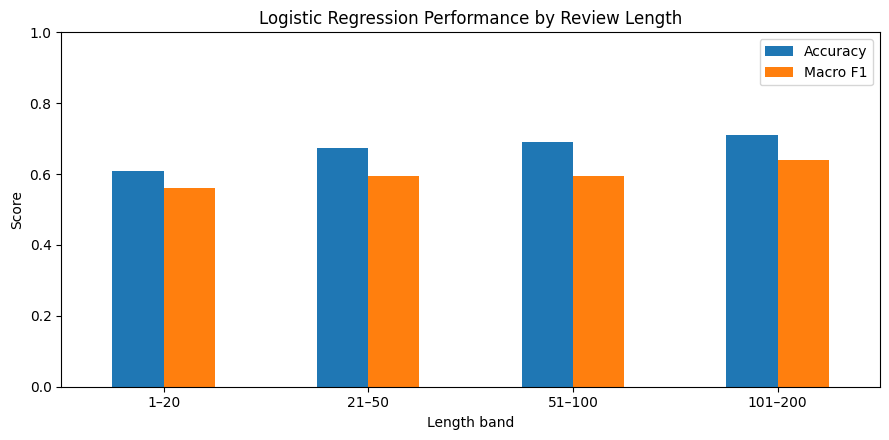

In [30]:
length_bins = [0, 20, 50, 100, 200, np.inf]
length_labels = ["1–20", "21–50", "51–100", "101–200", "201+"]
error_analysis["length_band"] = pd.cut(
    error_analysis["review_length"], bins=length_bins, labels=length_labels,
    include_lowest=True,
)

length_rows = []
for length_band, group in error_analysis.groupby("length_band", observed=False):
    if group.empty:
        continue
    length_rows.append({
        "Length band": str(length_band),
        "Reviews": len(group),
        "Accuracy": accuracy_score(group["true_class_id"], group["predicted_class_id"]),
        "Macro F1": f1_score(
            group["true_class_id"], group["predicted_class_id"],
            labels=LABELS, average="macro", zero_division=0,
        ),
    })
length_performance = pd.DataFrame(length_rows)
display(length_performance.round(4))
length_performance.to_csv(ARTIFACT_DIR / "performance_by_review_length.csv", index=False)

axis = length_performance.set_index("Length band")[["Accuracy", "Macro F1"]].plot(
    kind="bar", figsize=(9, 4.5)
)
axis.set_ylim(0, 1)
axis.set_ylabel("Score")
axis.set_title(f"{best_model_name} Performance by Review Length")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "performance_by_review_length.png", dpi=300, bbox_inches="tight")
plt.show()


# 10. Save Reusable Artifacts

The notebook saves only runtime outputs under:

```text
Project NLP/artifacts/supervised_xai/
```

These files are **outputs, not input dependencies**. The notebook can always start again from
the original Kaggle WebMD source without any parquet file or previously generated Notebook 04 folder.


In [31]:
# Save traditional models.
joblib.dump(final_lr_pipeline, ARTIFACT_DIR / "logistic_regression_pipeline.joblib")
joblib.dump(final_svm_pipeline, ARTIFACT_DIR / "linear_svm_pipeline.joblib")

# Save BiLSTM components.
torch.save(best_model_state, ARTIFACT_DIR / "bilstm_state_dict.pt")
(ARTIFACT_DIR / "bilstm_vocab.json").write_text(
    json.dumps(vocabulary, ensure_ascii=False), encoding="utf-8"
)
bilstm_config = {
    "vocabulary_size": len(vocabulary),
    "embedding_dimension": 128,
    "hidden_dimension": 128,
    "output_dimension": 3,
    "dropout_probability": 0.30,
    "sequence_length": SEQUENCE_LENGTH,
    "max_vocabulary_size": MAX_VOCAB_SIZE,
    "minimum_frequency": MIN_FREQUENCY,
    "best_epoch": best_epoch,
    "best_validation_macro_f1": float(best_validation_f1),
    "class_names": CLASS_NAMES,
    "seed": SEED,
}
(ARTIFACT_DIR / "bilstm_config.json").write_text(
    json.dumps(bilstm_config, indent=2), encoding="utf-8"
)

# Save one test table with every model's predictions/confidence.
test_predictions = test_df[[
    column for column in ["row_id", "review_non_lem", "target", "sentiment", "Condition", "Drug"]
    if column in test_df.columns
]].copy()
for model_name in model_predictions:
    safe_name = model_name.lower().replace(" ", "_")
    predictions = np.asarray(model_predictions[model_name])
    test_predictions[f"{safe_name}_prediction"] = predictions
    test_predictions[f"{safe_name}_prediction_label"] = [CLASS_NAMES[value] for value in predictions]
    test_predictions[f"{safe_name}_confidence"] = np.asarray(model_confidences[model_name])

test_predictions.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)
metrics_comparison.to_csv(ARTIFACT_DIR / "metrics_comparison.csv", index=False)
split_ids.to_csv(ARTIFACT_DIR / "split_ids.csv", index=False)

print("Saved model and data artifacts:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    if path.is_file():
        print(f"- {path.name}: {path.stat().st_size:,} bytes")


Saved model and data artifacts:
- bilstm_config.json: 378 bytes
- bilstm_confusion_matrices.png: 130,313 bytes
- bilstm_learning_curves.png: 175,818 bytes
- bilstm_state_dict.pt: 10,117,996 bytes
- bilstm_vocab.json: 312,410 bytes
- error_analysis.csv: 1,486,667 bytes
- lime_correct_negative.html: 1,232,522 bytes
- lime_correct_negative.png: 97,218 bytes
- lime_correct_positive.html: 1,232,348 bytes
- lime_correct_positive.png: 95,784 bytes
- lime_examples_summary.csv: 512 bytes
- lime_misclassified_or_low_confidence.html: 1,232,756 bytes
- lime_misclassified_or_low_confidence.png: 111,332 bytes
- linear_svm_confusion_matrices.png: 126,464 bytes
- linear_svm_pipeline.joblib: 630,480 bytes
- logistic_coefficients_negative.csv: 1,254 bytes
- logistic_coefficients_negative.png: 164,775 bytes
- logistic_coefficients_neutral.csv: 1,276 bytes
- logistic_coefficients_neutral.png: 170,930 bytes
- logistic_coefficients_positive.csv: 1,258 bytes
- logistic_coefficients_positive.png: 165,179 byte

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
print("Source dependency used by this notebook:")
print(f"- Kaggle dataset: {DATASET_ID}")
print(f"- Raw CSV selected: {RAW_DATA_PATH}")
print("- No df_lem_final.parquet dependency")
print("- No df_non_lem_final.parquet dependency")
print("- No generated Notebook 04 support-file dependency")


Source dependency used by this notebook:
- Kaggle dataset: rohanharode07/webmd-drug-reviews-dataset
- Raw CSV selected: /root/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1/webmd.csv
- No df_lem_final.parquet dependency
- No df_non_lem_final.parquet dependency
- No generated Notebook 04 support-file dependency


# 11. Conclusions, Limitations, and Report Notes

The next cell generates a concise result summary from the actual executed metrics. It is intentionally data-driven: no performance value or finding is written before the experiment runs.

Key methodological points for the report and oral presentation:

- The target is a three-class sentiment interpretation of Satisfaction.
- Rating fields and metadata were excluded from input to prevent leakage.
- A single duplicate-safe stratified split enabled fair comparison.
- TF-IDF was fitted on training data only.
- Macro F1 was primary because all three classes should matter equally.
- Non-lemmatized sequences were retained for the BiLSTM to preserve word order and natural forms.
- Coefficients, LIME, and SHAP describe model behavior, not medical causality.

Limitations include imperfect rating-derived sentiment labels, class imbalance, spelling/noise, mixed sentiment, domain/platform bias, finite computational resources, and the approximate nature of post-hoc XAI. Future work could compare a fine-tuned transformer, ordinal targets, probability calibration, metadata ablation, and external validation.


In [33]:
best_row = metrics_comparison.iloc[0]
neutral_f1_values = {}
for model_name, report in classification_reports.items():
    neutral_f1_values[model_name] = float(report.loc["Neutral", "f1-score"])

summary_markdown = f"""
## Executed Findings Summary

- **Best final model by macro F1:** {best_row['Model']}
- **Best macro F1:** {best_row['Macro F1']:.4f}
- **Best accuracy:** {best_row['Accuracy']:.4f}
- **Best weighted F1:** {best_row['Weighted F1']:.4f}
- **SHAP execution status:** {SHAP_STATUS}
- **BiLSTM best epoch:** {best_epoch}
- **BiLSTM best validation macro F1:** {best_validation_f1:.4f}

Neutral-class F1 by model:
"""
summary_markdown += "\n".join(
    f"- {model_name}: {score:.4f}" for model_name, score in neutral_f1_values.items()
)
display(Markdown(summary_markdown))



## Executed Findings Summary

- **Best final model by macro F1:** Logistic Regression
- **Best macro F1:** 0.5840
- **Best accuracy:** 0.6509
- **Best weighted F1:** 0.6680
- **SHAP execution status:** PASS
- **BiLSTM best epoch:** 5
- **BiLSTM best validation macro F1:** 0.5435

Neutral-class F1 by model:
- Dummy Majority: 0.0000
- Logistic Regression: 0.3079
- Linear SVM: 0.2545
- BiLSTM: 0.2377

In [34]:
# Final run record. This cell is reached only after all preceding mandatory sections execute.
runtime_seconds = time.perf_counter() - NOTEBOOK_START_TIME

required_artifacts = [
    "metrics_comparison.csv",
    "test_predictions.csv",
    "split_ids.csv",
    "logistic_regression_pipeline.joblib",
    "linear_svm_pipeline.joblib",
    "bilstm_state_dict.pt",
    "bilstm_vocab.json",
    "bilstm_config.json",
    "bilstm_learning_curves.png",
    "logistic_regression_confusion_matrices.png",
    "linear_svm_confusion_matrices.png",
    "bilstm_confusion_matrices.png",
    "lime_correct_negative.html",
    "lime_correct_positive.html",
    "lime_misclassified_or_low_confidence.html",
]
artifact_checks = {
    filename: (ARTIFACT_DIR / filename).exists() and (ARTIFACT_DIR / filename).stat().st_size > 0
    for filename in required_artifacts
}
missing_required_artifacts = [name for name, valid in artifact_checks.items() if not valid]
validation_status = "PASS" if not missing_required_artifacts else "FAIL"

metrics_markdown = metrics_comparison.round(4).to_markdown(index=False)
artifact_lines = "\n".join(
    f"- {'PASS' if valid else 'FAIL'}: `{name}`" for name, valid in artifact_checks.items()
)

validation_text = f"""# Classification & XAI Run Validation

- **Overall status:** {validation_status}
- **Run started:** {RUN_STARTED_AT}
- **Run finished:** {datetime.now().isoformat(timespec='seconds')}
- **Total runtime:** {runtime_seconds:.2f} seconds ({runtime_seconds / 60:.2f} minutes)
- **Python:** {platform.python_version()}
- **Platform:** {platform.platform()}
- **Device:** {DEVICE}
- **Smoke-test mode:** {SMOKE_TEST}
- **Configured sample size:** {SAMPLE_SIZE:,}
- **Actual sample size:** {len(sample_df):,}
- **Train / validation / test:** {len(train_df):,} / {len(validation_df):,} / {len(test_df):,}
- **Kaggle dataset:** `{DATASET_ID}`
- **Raw source input:** `{RAW_DATA_PATH}`
- **SHAP status:** {SHAP_STATUS}
- **SHAP error (when applicable):** {SHAP_ERROR}

## Final metrics

{metrics_markdown}

## Required artifact checks

{artifact_lines}

## Notes

- TF-IDF was fitted inside fresh training-only pipelines.
- One shared duplicate-safe split was used across every model.
- Validation data selected traditional hyperparameters and controlled BiLSTM early stopping.
- Test data was evaluated after model selection.
- A SHAP compatibility failure is non-fatal only because coefficient and LIME explanations remain complete and the error is reported transparently.
"""

(ARTIFACT_DIR / "RUN_VALIDATION.md").write_text(validation_text, encoding="utf-8")
print(validation_text)

if missing_required_artifacts:
    raise RuntimeError(f"Required artifacts are missing or empty: {missing_required_artifacts}")


# Classification & XAI Run Validation

- **Overall status:** PASS
- **Run started:** 2026-07-12T07:02:30
- **Run finished:** 2026-07-12T07:19:51
- **Total runtime:** 1040.54 seconds (17.34 minutes)
- **Python:** 3.12.13
- **Platform:** Linux-6.6.122+-x86_64-with-glibc2.35
- **Device:** cpu
- **Smoke-test mode:** False
- **Configured sample size:** 30,000
- **Actual sample size:** 30,000
- **Train / validation / test:** 21,000 / 4,500 / 4,500
- **Kaggle dataset:** `rohanharode07/webmd-drug-reviews-dataset`
- **Raw source input:** `/root/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1/webmd.csv`
- **SHAP status:** PASS
- **SHAP error (when applicable):** None

## Final metrics

| Model               | Representation                                         |   Accuracy |   Macro Precision |   Macro Recall |   Macro F1 |   Weighted F1 |   Training Time (s) |   Inference Time (s) |
|:--------------------|:-------------------------------------------------------|